In [1]:
import warnings
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pertpy as pt
import scanpy as sc
import seaborn as sns
import anndata as ad



warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")

/rds/general/user/ztb25/home/miniforge3/envs/sccoda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load in data

adata = sc.read("/rds/general/user/ztb25/home/PBMC_datasets/integrated_adata_scANVI.h5ad")

In [3]:
adata

AnnData object with n_obs × n_vars = 880872 × 12711
    obs: 'age', 'gender', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'dataset', 'sample_combined'
    var: 'feature_types', 'mt', 'gene_symbols', 'genome', 'gene_versions', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'dataset_colors', 'hvg', 'neighbors', 'pca', 'sample_combined_colors', 'scANVI', 'umap'
    obsm: 'X_pca', 'X_scANVI', 'X_umap_scANVI', 'X_umap_unintegrated'
    varm: 'PCs'
    layers: 'counts', 'log1p_norm'
    obsp: 'connectivities', 'connectivities_unintegrated', 'distances', 'distances_unintegrated', 'scAN

In [4]:
adata.obs["dataset"].value_counts()

dataset
6    452499
4    295440
5     78876
1     54057
Name: count, dtype: int64

In [5]:
# Bringing back diagnosis column, needed for composition analysis, that got dropped at concatenation.

# the per-dataset files that DO have diagnosis
files = {
    "1": "/rds/general/user/ztb25/home/PBMC_datasets/1/PBMC1_clustering.h5ad",
    "4": "/rds/general/user/ztb25/home/PBMC_datasets/4/PBMC4_clustering.h5ad",
    "5": "/rds/general/user/ztb25/home/PBMC_datasets/5/PBMC5_clustering.h5ad",
    "6": "/rds/general/user/ztb25/home/PBMC_datasets/6/PBMC6_clustering.h5ad",
}

# build a barcode -> diagnosis lookup, reconstructing the integrated barcode format
diag_map = {}
for ds, path in files.items():
    a = ad.read_h5ad(path, backed="r")
    integrated_barcodes = a.obs_names + f"-{ds}"
    if "diagnosis" in a.obs.columns:
        diags = a.obs["diagnosis"].astype(str).tolist()
    else:
        diags = ["CTRL"] * a.n_obs          # dataset 6 — no column, all controls
    diag_map.update(dict(zip(integrated_barcodes, diags)))
    a.file.close()

adata.obs["diagnosis"] = adata.obs_names.map(diag_map)

In [6]:
import gc
del diag_map                
try:
    del a                    
except NameError:
    pass
gc.collect()

adata.obs["diagnosis"] = adata.obs["diagnosis"].astype("category")


In [7]:
# Count number of samples per diagnosis group
n_samples_per_diagnosis = adata.obs[adata.obs["dataset"] == "6"].groupby("diagnosis")["sample"].nunique()
print("Number of samples per diagnosis group:")
print(n_samples_per_diagnosis)

Number of samples per diagnosis group:
diagnosis
AD       0
CTRL    23
PD       0
Name: sample, dtype: int64


In [8]:
# change diagnosis and dataset to categorical for sccoda
adata.obs["diagnosis"] = adata.obs["diagnosis"].astype("category")
adata.obs["dataset"]   = adata.obs["dataset"].astype("category")

adata.obs["diagnosis"].dtype
adata.obs["dataset"].dtype

CategoricalDtype(categories=['1', '4', '5', '6'], ordered=False, categories_dtype=object)

In [ ]:
# #instantiate scCODA model and create MuData object 

# sccoda_model = pt.tl.Sccoda()
# sccoda_data = sccoda_model.load(
#     adata,
#     type="cell_level",
#     generate_sample_level=True,
#     cell_type_identifier="celltypist_cell_label_fine",
#     sample_identifier="sample_combined",
#     covariate_obs=["diagnosis", "dataset"], # sex and age
# )
# sccoda_data

MuData object with n_obs × n_vars = 880975 × 12735
  2 modalities
    rna:	880872 x 12711
      obs:	'age', 'gender', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'dataset', 'sample_combined', 'diagnosis', 'scCODA_sample_id'
      var:	'feature_types', 'mt', 'gene_symbols', 'genome', 'gene_versions', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
      uns:	'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'dataset_colors', 'hvg', 'neighbors', 'pca', 'sample_combined_colors', 'scANVI', 'umap'
      obsm:	'X_pca', 'X_scANVI', 'X_umap_scANVI', 'X_umap_unintegrated'
      varm:	'PCs'
      layers:	'counts', 'log1p_norm'
      obsp:	'connectivities', 'connectivities_unintegrated', 'distances', 'distances_unintegrated', 'scANVI_connectivities', 'scANVI_distances'
    coda:	103 x 24
      obs:	'sample_combined', 'diagnosis', 'dataset'
      var:	'n_cells'

In [ ]:
# # get cell fractions per sammple, mean and standard deviation per group (fine annotations)

# # counts table: rows = samples, columns = cell types
# counts = sccoda_data["coda"].X

# # convert to dataframe
# counts_df = pd.DataFrame(
#     counts,
#     index=sccoda_data["coda"].obs_names,
#     columns=sccoda_data["coda"].var_names
# )

# # calculate fractions per sample
# fractions = counts_df.div(counts_df.sum(axis=1), axis=0)

# # add metadata (e.g. diagnosis)
# fractions["diagnosis"] = sccoda_data["coda"].obs["diagnosis"].values

# fractions

In [ ]:
# summary = fractions.groupby("diagnosis").agg(["mean", "std"])

# print(summary.to_string())

In [ ]:
# # Pooled SD for every fine cell type, for the power analysis.

# def pooled_sd(case_fractions, ref_fractions):
#     """Two-sample pooled SD, equal-variance assumption. NaN if either group has <2 samples."""
#     n_case, n_ref = len(case_fractions), len(ref_fractions)
#     if n_case < 2 or n_ref < 2:
#         return np.nan
#     s_case, s_ref = case_fractions.std(ddof=1), ref_fractions.std(ddof=1)
#     return np.sqrt(((n_case - 1) * s_case**2 + (n_ref - 1) * s_ref**2) / (n_case + n_ref - 2))


# cell_type_columns = [col for col in fractions.columns if col != "diagnosis"]
# comparisons = [("PD", "CTRL"), ("AD", "CTRL"), ("PD", "AD")]

# pooled_sd_rows = []
# for case_group, ref_group in comparisons:
#     for cell_type in cell_type_columns:
#         case_fractions = fractions.loc[fractions["diagnosis"] == case_group, cell_type]
#         ref_fractions  = fractions.loc[fractions["diagnosis"] == ref_group,  cell_type]

#         sd = pooled_sd(case_fractions, ref_fractions)
#         mean_difference = case_fractions.mean() - ref_fractions.mean()

#         pooled_sd_rows.append({
#             "comparison":  f"{case_group}_vs_{ref_group}",
#             "cell_type":   cell_type,
#             "n_case":      len(case_fractions),
#             "n_ref":       len(ref_fractions),
#             "mean_case":   case_fractions.mean(),
#             "mean_ref":    ref_fractions.mean(),
#             "sd_case":     case_fractions.std(ddof=1),
#             "sd_ref":      ref_fractions.std(ddof=1),
#             "pooled_sd":   sd,
#             "mean_diff":   mean_difference,
#             # effect size the power calculation actually consumes
#             "cohens_d":    mean_difference / sd if (sd and sd > 0) else np.nan,
#         })

# pooled_sd_table = pd.DataFrame(pooled_sd_rows)

# # to_string() ignores pandas' display options entirely, so nothing is truncated in the job log
# print(pooled_sd_table.to_string(index=False, float_format=lambda v: f"{v:.5f}"))

# # also write it out — easier than scraping the log, and you'll want it in the dissertation as a table
# pooled_sd_table.to_csv("pooled_sd_fine_celltypes.csv", index=False)


In [ ]:
# # (for power analysis, computing pooled standard deviation for one of the cell types)

# from unittest import case


# ctrl = fractions[fractions["diagnosis"] == "CTRL"]["Classical monocytes"]
# cases_pd = fractions[fractions["diagnosis"] == "PD"]["Classical monocytes"]

# s1 = ctrl.std(ddof=1)
# s2 = cases_pd.std(ddof=1)

# n1 = len(ctrl)
# n2 = len(cases_pd)

# pooled_sd = np.sqrt(
#     ((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2)
# )

# print(pooled_sd)

In [ ]:
# # (for power analysis, computing pooled standard deviation for one of the cell types)

# ctrl = fractions[fractions["diagnosis"] == "CTRL"]["Plasma cells"]
# cases_ad = fractions[fractions["diagnosis"] == "AD"]["Plasma cells"]

# s1 = ctrl.std(ddof=1)
# s2 = cases_ad.std(ddof=1)

# n1 = len(ctrl)
# n2 = len(cases_ad)

# pooled_sd = np.sqrt(
#     ((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2)
# )

# print(pooled_sd)

In [ ]:
# # ensure correction ordering of categories for reference levels in sccoda (CTRL for diagnosis, dataset 6 for dataset)

# sccoda_data["coda"].obs["diagnosis"] = (
#     sccoda_data["coda"].obs["diagnosis"].cat.reorder_categories(["CTRL", "PD", "AD"])
# )

# sccoda_data["coda"].obs["dataset"] = (
#     sccoda_data["coda"].obs["dataset"].cat.reorder_categories(["6", "1", "4", "5"])
# )

In [ ]:
# # run scCODA model
# sccoda_data = sccoda_model.prepare(
#     sccoda_data,
#     modality_key="coda",
#     formula="diagnosis + dataset", # check this is still ok to do since dataset 6 is all CTRL (collinearity between diagnosis and dataset)
#     reference_cell_type="automatic", # letting scCODA choose the reference cell type automatically
# )
# sccoda_model.run_nuts(sccoda_data, modality_key="coda", rng_key=1234)

sample: 100%|██████████| 11000/11000 [45:14<00:00,  4.05it/s, 511 steps of size 8.59e-03. acc. prob=0.84] 


In [11]:
# # subset to PD + CTRL before loading into scCODA
# mask = adata.obs["diagnosis"].isin(["PD", "CTRL"])
# adata_pd = adata[mask].copy()
# adata_pd.obs["diagnosis"] = adata_pd.obs["diagnosis"].cat.remove_unused_categories()
# adata_pd.obs["dataset"]   = adata_pd.obs["dataset"].cat.remove_unused_categories()

# # rebuild scCODA on the subset
# sccoda_data = sccoda_model.load(
#     adata_pd, type="cell_level", generate_sample_level=True,
#     cell_type_identifier="celltypist_cell_label_coarse",
#     sample_identifier="sample_combined",
#     covariate_obs=["diagnosis", "dataset"],
# )
# sccoda_data["coda"].obs["diagnosis"] = (
#     sccoda_data["coda"].obs["diagnosis"].cat.reorder_categories(["CTRL", "PD"])
# )
# sccoda_data = sccoda_model.prepare(
#     sccoda_data, modality_key="coda",
#     formula="diagnosis + dataset", reference_cell_type="automatic",
# )
# sccoda_model.run_nuts(sccoda_data, modality_key="coda", rng_key=1234)

In [ ]:
# sccoda_data["coda"].varm["effect_df_diagnosis[T.PD]"]

# # Final parameter tells us if a credible effect was found (non zero), and “Expected sample” and “log2-fold change” columns give us an idea on the magnitude of the change. HDI 3% / HDI 97% — credible interval bounds.

,Final Parameter,HDI 3%,HDI 97%,SD,Inclusion probability,Expected Sample,log2-fold change
celltypist_cell_label_fine,,,,,,,
Age-associated B cells,0.0,-0.200,0.194,0.071,0.5185,79.290412,0.0
CD16+ NK cells,0.0,-0.112,0.164,0.052,0.4848,1196.453704,0.0
Classical monocytes,0.0,-0.043,0.302,0.098,0.6815,887.241502,0.0
DC1,0.0,-0.186,0.243,0.081,0.5101,32.431080,0.0
DC2,0.0,-0.164,0.246,0.075,0.4762,116.759611,0.0
ETP,0.0,0.000,0.000,0.000,0.0000,37.604255,0.0
HSC/MPP,0.0,-0.257,0.174,0.079,0.4772,44.930516,0.0
ILC3,0.0,-0.276,0.165,0.081,0.4927,45.884034,0.0
MAIT cells,0.0,-0.184,0.204,0.069,0.4820,169.375342,0.0


In [ ]:
# # checking effects, should be one effect dataframe per covariate level
# print([k for k in sccoda_data["coda"].varm.keys() if k.startswith("effect_df")])

['effect_df_diagnosis[T.PD]', 'effect_df_diagnosis[T.AD]', 'effect_df_dataset[T.4]', 'effect_df_dataset[T.5]', 'effect_df_dataset[T.6]']


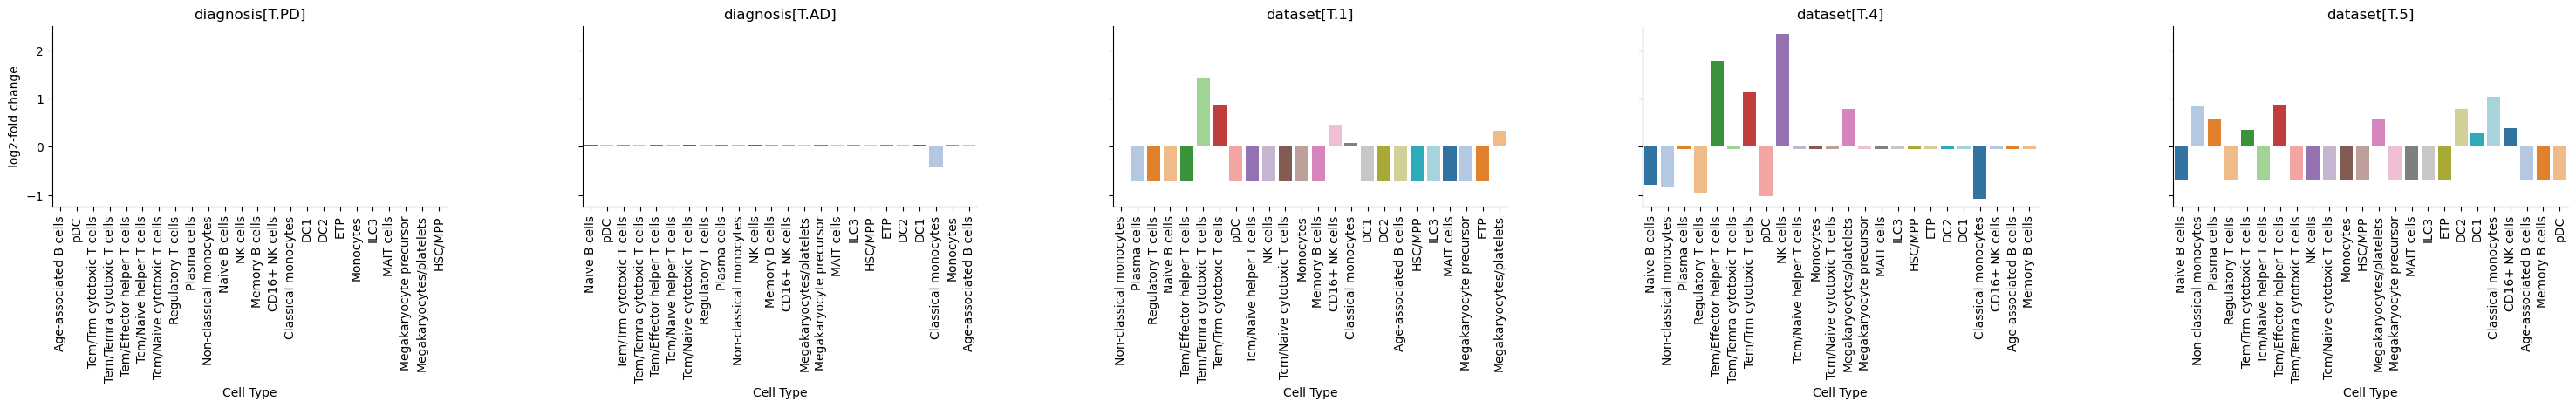

In [ ]:
# sccoda_model.plot_effects_barplot(
#     sccoda_data, modality_key="coda",
#     parameter="log2-fold change",
# )

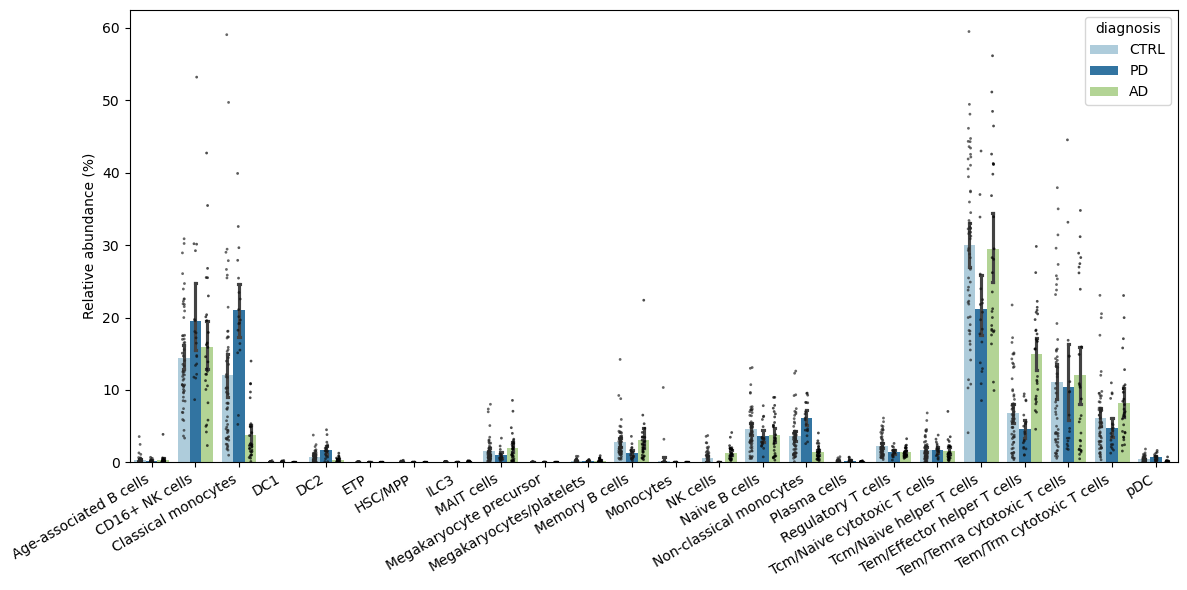

In [ ]:
# # plot relative abundances of cell types across the two conditions
# coda = sccoda_data["coda"]

# # Build relative-abundance long-format dataframe in one chain
# plot_df = (
#     pd.DataFrame(coda.X, index=coda.obs_names, columns=coda.var_names)
#     .pipe(lambda df: df.div(df.sum(axis=1), axis=0) * 100)
#     .assign(diagnosis=coda.obs["diagnosis"].values)
#     .reset_index(names="sample_combined")
#     .melt(id_vars=["sample_combined", "diagnosis"], var_name="cell_type", value_name="rel_abundance")
# )

# cell_types = plot_df["cell_type"].unique().tolist()

# fig, ax = plt.subplots(figsize=(12, 6))

# sns.barplot(
#     data=plot_df, x="cell_type", y="rel_abundance", hue="diagnosis",
#     errorbar=("ci", 95), capsize=0.1, palette="Paired", ax=ax
# )
# sns.stripplot(
#     data=plot_df, x="cell_type", y="rel_abundance", hue="diagnosis",
#     dodge=True, color="black", alpha=0.7, size=2, legend=False, ax=ax
# )

# ax.set_xlabel("")
# ax.set_ylabel("Relative abundance (%)")
# plt.xticks(rotation=30, ha="right")
# plt.tight_layout()
# plt.show()

# # two different scales/plot, to show differences for rare cell types more clearly



In [ ]:
# # trying with a less stringent FDR threshold to see if any cell types are identified as differentially abundant
# sccoda_model.set_fdr(sccoda_data, 0.2)
# credible = sccoda_model.credible_effects(sccoda_data, modality_key="coda")
# credible

Covariate        Cell Type                  
diagnosis[T.PD]  Age-associated B cells          True
                 CD16+ NK cells                 False
                 Classical monocytes             True
                 DC1                            False
                 DC2                            False
                                                ...  
dataset[T.5]     Tcm/Naive helper T cells        True
                 Tem/Effector helper T cells     True
                 Tem/Temra cytotoxic T cells    False
                 Tem/Trm cytotoxic T cells       True
                 pDC                            False
Name: Final Parameter, Length: 120, dtype: bool

In [ ]:
# effect_df_PD = sccoda_data["coda"].varm["effect_df_diagnosis[T.PD]"]
# effect_df_PD[effect_df_PD["Final Parameter"] != 0]

,Final Parameter,HDI 3%,HDI 97%,SD,Inclusion probability,Expected Sample,log2-fold change
celltypist_cell_label_fine,,,,,,,
Age-associated B cells,-0.004272,-0.200,0.194,0.071,0.5185,77.895345,-0.025609
Classical monocytes,0.106250,-0.043,0.302,0.098,0.6815,973.490678,0.133840
Non-classical monocytes,0.046257,-0.108,0.257,0.075,0.5244,352.444995,0.047288
Regulatory T cells,-0.038186,-0.246,0.139,0.077,0.5250,321.967963,-0.074537
Tcm/Naive cytotoxic T cells,0.061230,-0.124,0.318,0.092,0.5402,224.722915,0.068890


In [ ]:
# pd_credible = credible.loc["diagnosis[T.PD]"]   # just the PD effects
# pd_sig_celltypes = pd_credible[pd_credible].index.tolist()
# print("PD-credible cell types (FDR 0.2):", pd_sig_celltypes)

PD-credible cell types (FDR 0.2): ['Age-associated B cells', 'Classical monocytes', 'Non-classical monocytes', 'Regulatory T cells', 'Tcm/Naive cytotoxic T cells']


In [ ]:
# effect_df_AD = sccoda_data["coda"].varm["effect_df_diagnosis[T.AD]"]
# effect_df_AD[effect_df_AD["Final Parameter"] != 0]

,Final Parameter,HDI 3%,HDI 97%,SD,Inclusion probability,Expected Sample,log2-fold change
celltypist_cell_label_fine,,,,,,,
Age-associated B cells,-0.076439,-0.346,0.187,0.112,0.5154,76.890684,-0.044338
Classical monocytes,-0.314560,-0.636,0.016,0.206,0.8719,678.078473,-0.387875
DC2,-0.144900,-0.499,0.112,0.154,0.6172,105.733664,-0.143107
Non-classical monocytes,-0.133444,-0.448,0.138,0.140,0.5857,312.429685,-0.126579
Tem/Effector helper T cells,0.152141,-0.043,0.364,0.118,0.6292,357.796612,0.285434
Tem/Temra cytotoxic T cells,-0.142991,-0.390,0.067,0.123,0.6061,637.677183,-0.140353
Tem/Trm cytotoxic T cells,-0.110925,-0.364,0.086,0.106,0.5161,295.863476,-0.094091


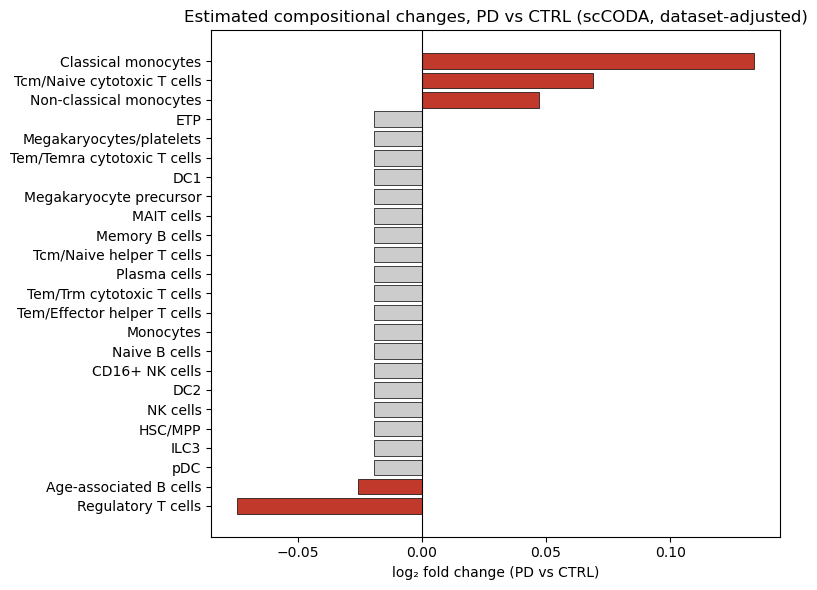

In [ ]:
# effect_df_PD["credible"] = effect_df_PD["Final Parameter"] != 0
# effect_df_PD = effect_df_PD.sort_values("log2-fold change")

# fig, ax = plt.subplots(figsize=(8, 6))
# colors = ["#C0392B" if c else "#cccccc" for c in effect_df_PD["credible"]]
# ax.barh(effect_df_PD.index, effect_df_PD["log2-fold change"], color=colors, edgecolor="black", linewidth=0.5)
# ax.axvline(0, color="black", linewidth=0.8)
# ax.set_xlabel("log₂ fold change (PD vs CTRL)")
# ax.set_title("Estimated compositional changes, PD vs CTRL (scCODA, dataset-adjusted)")
# plt.tight_layout()
# plt.show()

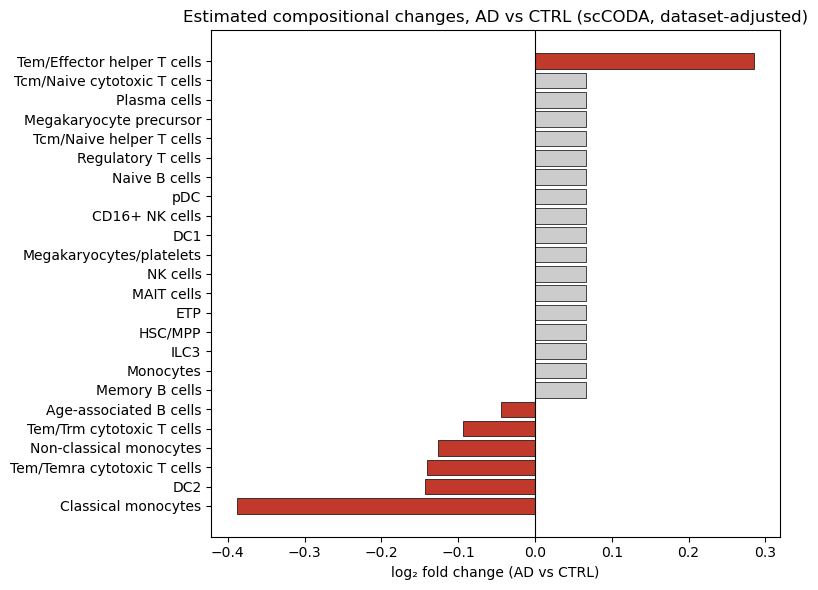

In [ ]:
# effect_df_AD["credible"] = effect_df_AD["Final Parameter"] != 0
# effect_df_AD = effect_df_AD.sort_values("log2-fold change")

# fig, ax = plt.subplots(figsize=(8, 6))
# colors = ["#C0392B" if c else "#cccccc" for c in effect_df_AD["credible"]]
# ax.barh(effect_df_AD.index, effect_df_AD["log2-fold change"], color=colors, edgecolor="black", linewidth=0.5)
# ax.axvline(0, color="black", linewidth=0.8)
# ax.set_xlabel("log₂ fold change (AD vs CTRL)")
# ax.set_title("Estimated compositional changes, AD vs CTRL (scCODA, dataset-adjusted)")
# plt.tight_layout()
# plt.show()

In [ ]:
# # try to run a disease (PD + AD) vs CTRL model, first need to add a column to adata

# adata.obs["condition"] = (
#     adata.obs["diagnosis"]
#     .replace({"PD": "disease", "AD": "disease"})
#     .astype("category")
# )

# # check
# print(adata.obs["condition"].value_counts())
# print(adata.obs.groupby("dataset")["condition"].value_counts())  # confirm 1/4/5 have both, 6 is CTRL-only

condition
CTRL       610260
disease    270612
Name: count, dtype: int64
dataset  condition
1        disease       37605
         CTRL          16452
4        disease      178164
         CTRL         117276
5        disease       54843
         CTRL          24033
6        CTRL         452499
         disease           0
Name: count, dtype: int64


In [ ]:
# sccoda_data = sccoda_model.load(
#     adata,
#     type="cell_level",
#     generate_sample_level=True,
#     cell_type_identifier="celltypist_cell_label_fine",  
#     sample_identifier="sample_combined",
#     covariate_obs=["condition", "dataset"],   
# )

# sccoda_data["coda"].obs["condition"] = (
#     sccoda_data["coda"].obs["condition"].cat.reorder_categories(["CTRL", "disease"])
# )

# sccoda_data = sccoda_model.prepare(
#     sccoda_data, modality_key="coda",
#     formula="condition + dataset", reference_cell_type="automatic",
# )
# sccoda_model.run_nuts(sccoda_data, modality_key="coda", rng_key=1234)


sample: 100%|██████████| 11000/11000 [44:55<00:00,  4.08it/s, 511 steps of size 9.27e-03. acc. prob=0.86] 


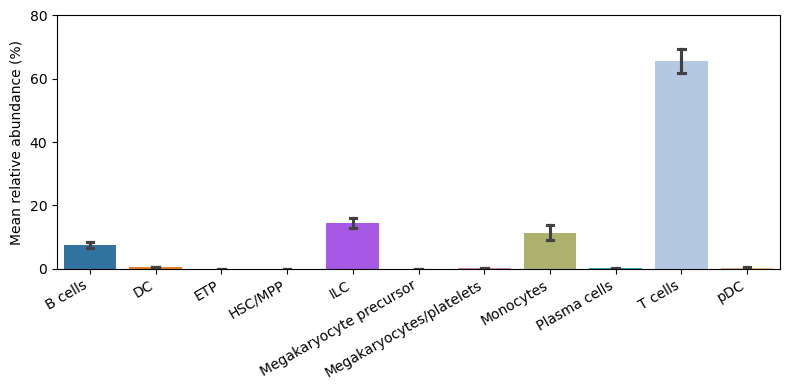

In [ ]:
# # plot overall relative abundance of each cell type across all samples with 95% CI, and colors corresponding to the cell types in UMAP

# # count cells per type per sample, then normalise to %
# plot_df = (
#     adata.obs.groupby(["sample", "celltypist_cell_label_coarse"])
#     .size()
#     .reset_index(name="count")
#     .assign(rel_abundance=lambda df: df.groupby("sample")["count"].transform(lambda x: x / x.sum() * 100))
# )

# # derive colors from adata
# labels = adata.obs["celltypist_cell_label_coarse"].astype("category").cat.categories
# colors = adata.uns["celltypist_cell_label_coarse_colors"]
# cell_type_colors_dict = dict(zip(labels, colors))

# plt.figure(figsize=(8, 4))
# sns.barplot(
#     data=plot_df,
#     x="celltypist_cell_label_coarse",  
#     y="rel_abundance",
#     hue="celltypist_cell_label_coarse",
#     palette=cell_type_colors_dict,
#     dodge=False,
#     legend=False,
#     errorbar=("ci", 95),
#     capsize=0.1,
# )

# plt.xticks(rotation=30, ha="right")
# plt.ylabel("Mean relative abundance (%)")
# plt.xlabel("")
# plt.ylim(0, 80)
# plt.yticks(np.arange(0, 81, 20))
# plt.tight_layout()
# plt.show()

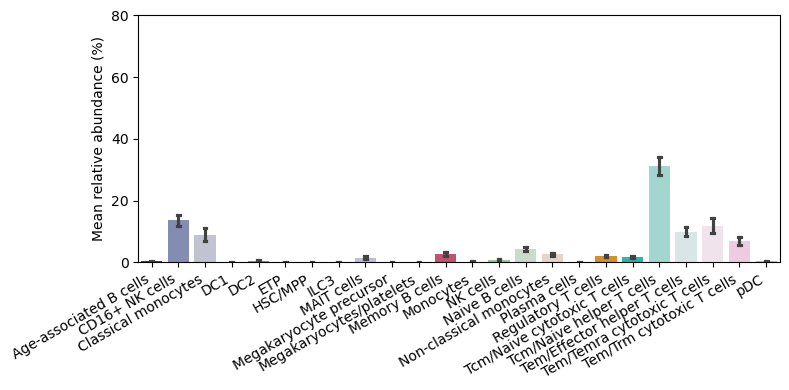

In [ ]:
# # plot overall relative abundance of each cell type across all samples with 95% CI, and colors corresponding to the cell types in UMAP

# # count cells per type per sample, then normalise to %
# plot_df = (
#     adata.obs.groupby(["sample", "celltypist_cell_label_fine"])
#     .size()
#     .reset_index(name="count")
#     .assign(rel_abundance=lambda df: df.groupby("sample")["count"].transform(lambda x: x / x.sum() * 100))
# )

# # derive colors from adata
# labels = adata.obs["celltypist_cell_label_fine"].astype("category").cat.categories
# colors = adata.uns["celltypist_cell_label_fine_colors"]
# cell_type_colors_dict = dict(zip(labels, colors))

# plt.figure(figsize=(8, 4))
# sns.barplot(
#     data=plot_df,
#     x="celltypist_cell_label_fine",  
#     y="rel_abundance",
#     hue="celltypist_cell_label_fine",
#     palette=cell_type_colors_dict,
#     dodge=False,
#     legend=False,
#     errorbar=("ci", 95),
#     capsize=0.1,
# )

# plt.xticks(rotation=30, ha="right")
# plt.ylabel("Mean relative abundance (%)")
# plt.xlabel("")
# plt.ylim(0, 80)
# plt.yticks(np.arange(0, 81, 20))
# plt.tight_layout()
# plt.show()

In [9]:
# Trying scanpro for compositional analysis

from scanpro.scanpro import scanpro

In [10]:
# standardise gender col
gender_map = {
    "M": "male", "F": "female",
    "Male": "male", "Female": "female",
    "male": "male", "female": "female",
}
adata.obs["gender"] = adata.obs["gender"].map(gender_map)

# make sure age is continuous
adata.obs["age"] = pd.to_numeric(adata.obs["age"], errors="coerce")

print(adata.obs["gender"].value_counts(dropna=False))
print(f"age NaN: {adata.obs['age'].isna().sum()}")

gender
female    532797
male      348075
Name: count, dtype: int64
age NaN: 0


In [26]:
out = scanpro(adata, samples_col='sample_combined', clusters_col='celltypist_cell_label_fine', conds_col='diagnosis', covariates = ['gender']) # default transformation is logit (can also specify transformation='arcsin')

out.results

[INFO] There are more than 2 conditions. ANOVA will be performed...
[INFO] Done!


,baseline_props,mean_props_CTRL,mean_props_PD,mean_props_AD,f_statistics,p_values,adjusted_p_values
clusters,,,,,,,
Age-associated B cells,0.003546,0.003459,0.001857,0.003123,2.723375,7.033872e-02,9.378496e-02
CD16+ NK cells,0.148680,0.144761,0.195907,0.159562,2.519514,8.540429e-02,1.078791e-01
Classical monocytes,0.113749,0.120204,0.210063,0.037837,32.113807,1.379941e-11,1.655929e-10
DC1,0.000149,0.000198,0.000785,0.000000,17.340948,3.169605e-07,7.607052e-07
DC2,0.007167,0.008139,0.017196,0.003161,19.143492,8.346357e-08,2.991946e-07
ETP,0.000195,0.000153,0.000000,0.000000,18.270927,1.585495e-07,4.756485e-07
HSC/MPP,0.000486,0.000399,0.000000,0.000000,18.077802,1.829406e-07,4.878416e-07
ILC3,0.000460,0.000384,0.000000,0.000610,26.057013,6.719368e-10,4.031621e-09
MAIT cells,0.014783,0.015218,0.009842,0.020354,1.285154,2.809652e-01,3.065075e-01


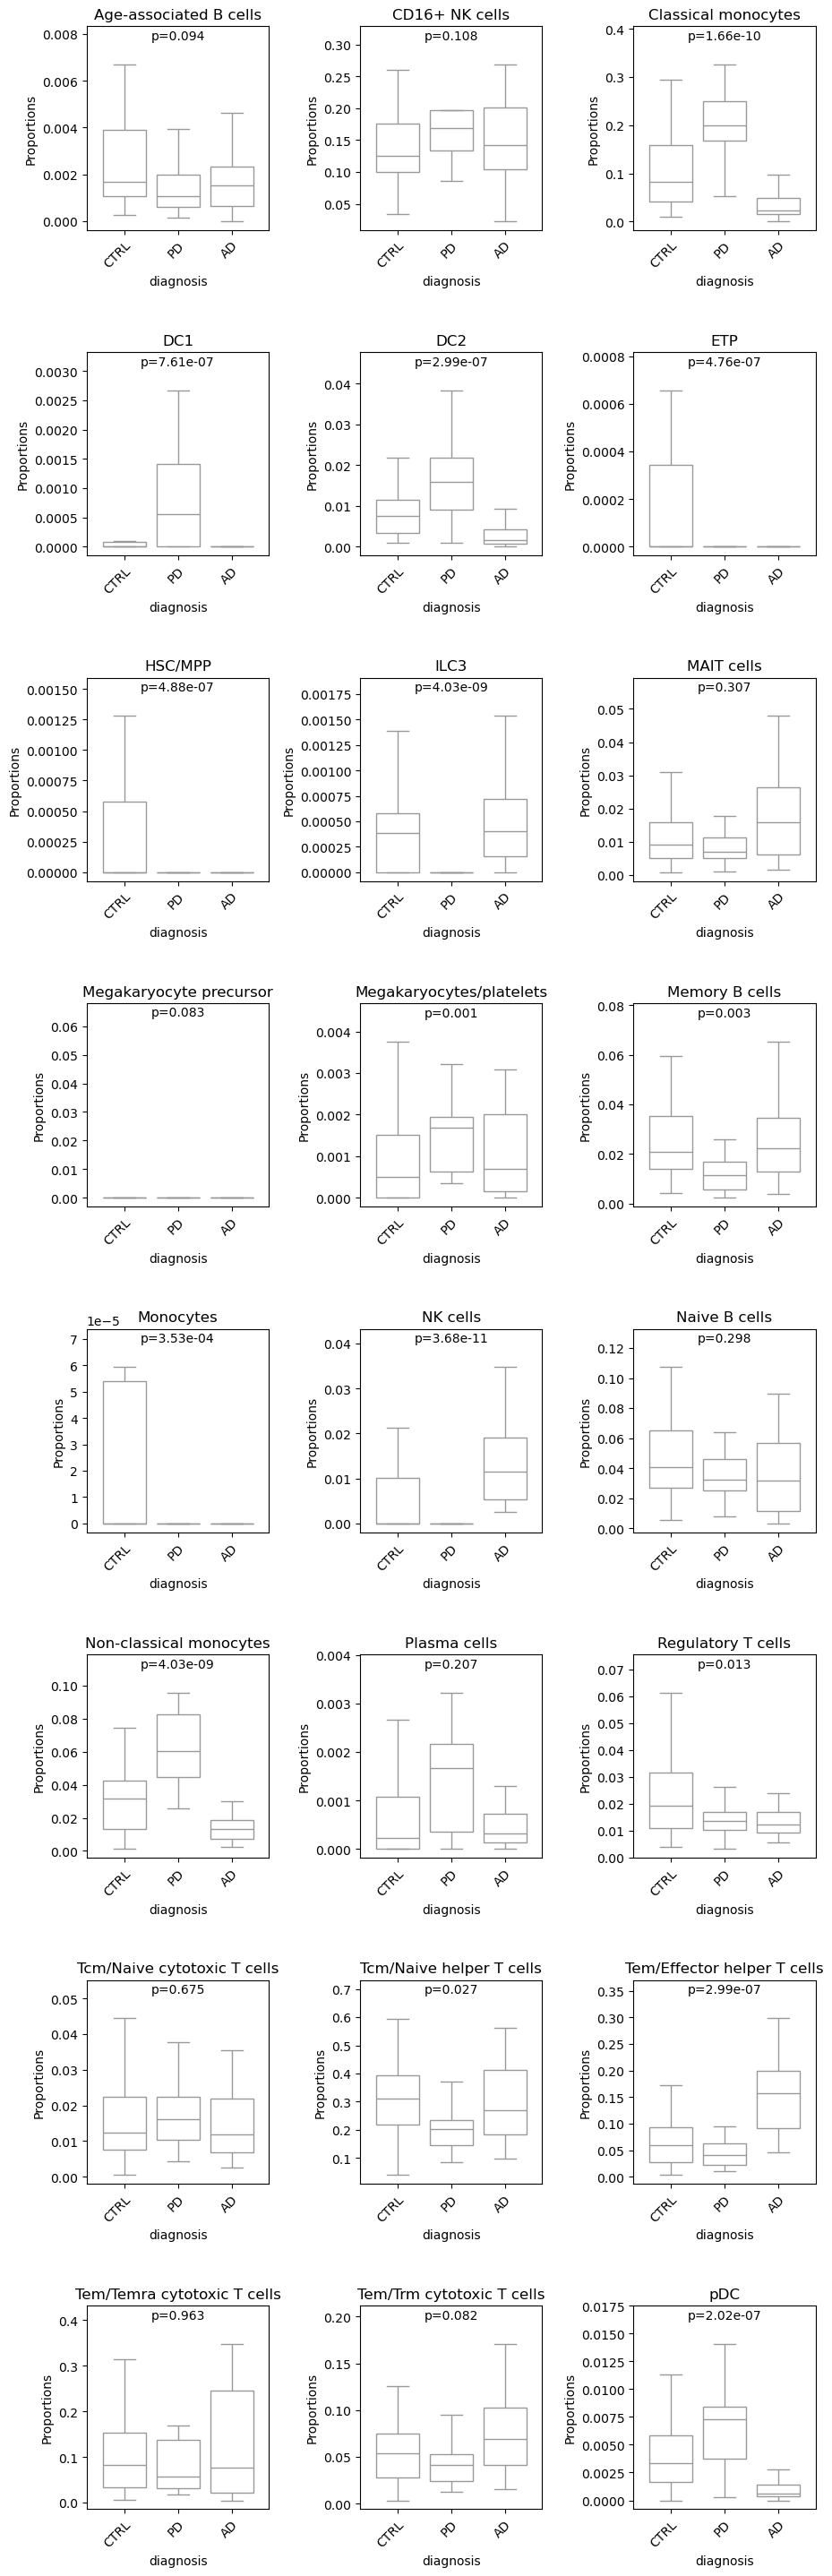

In [27]:
out.plot(kind='boxplot')

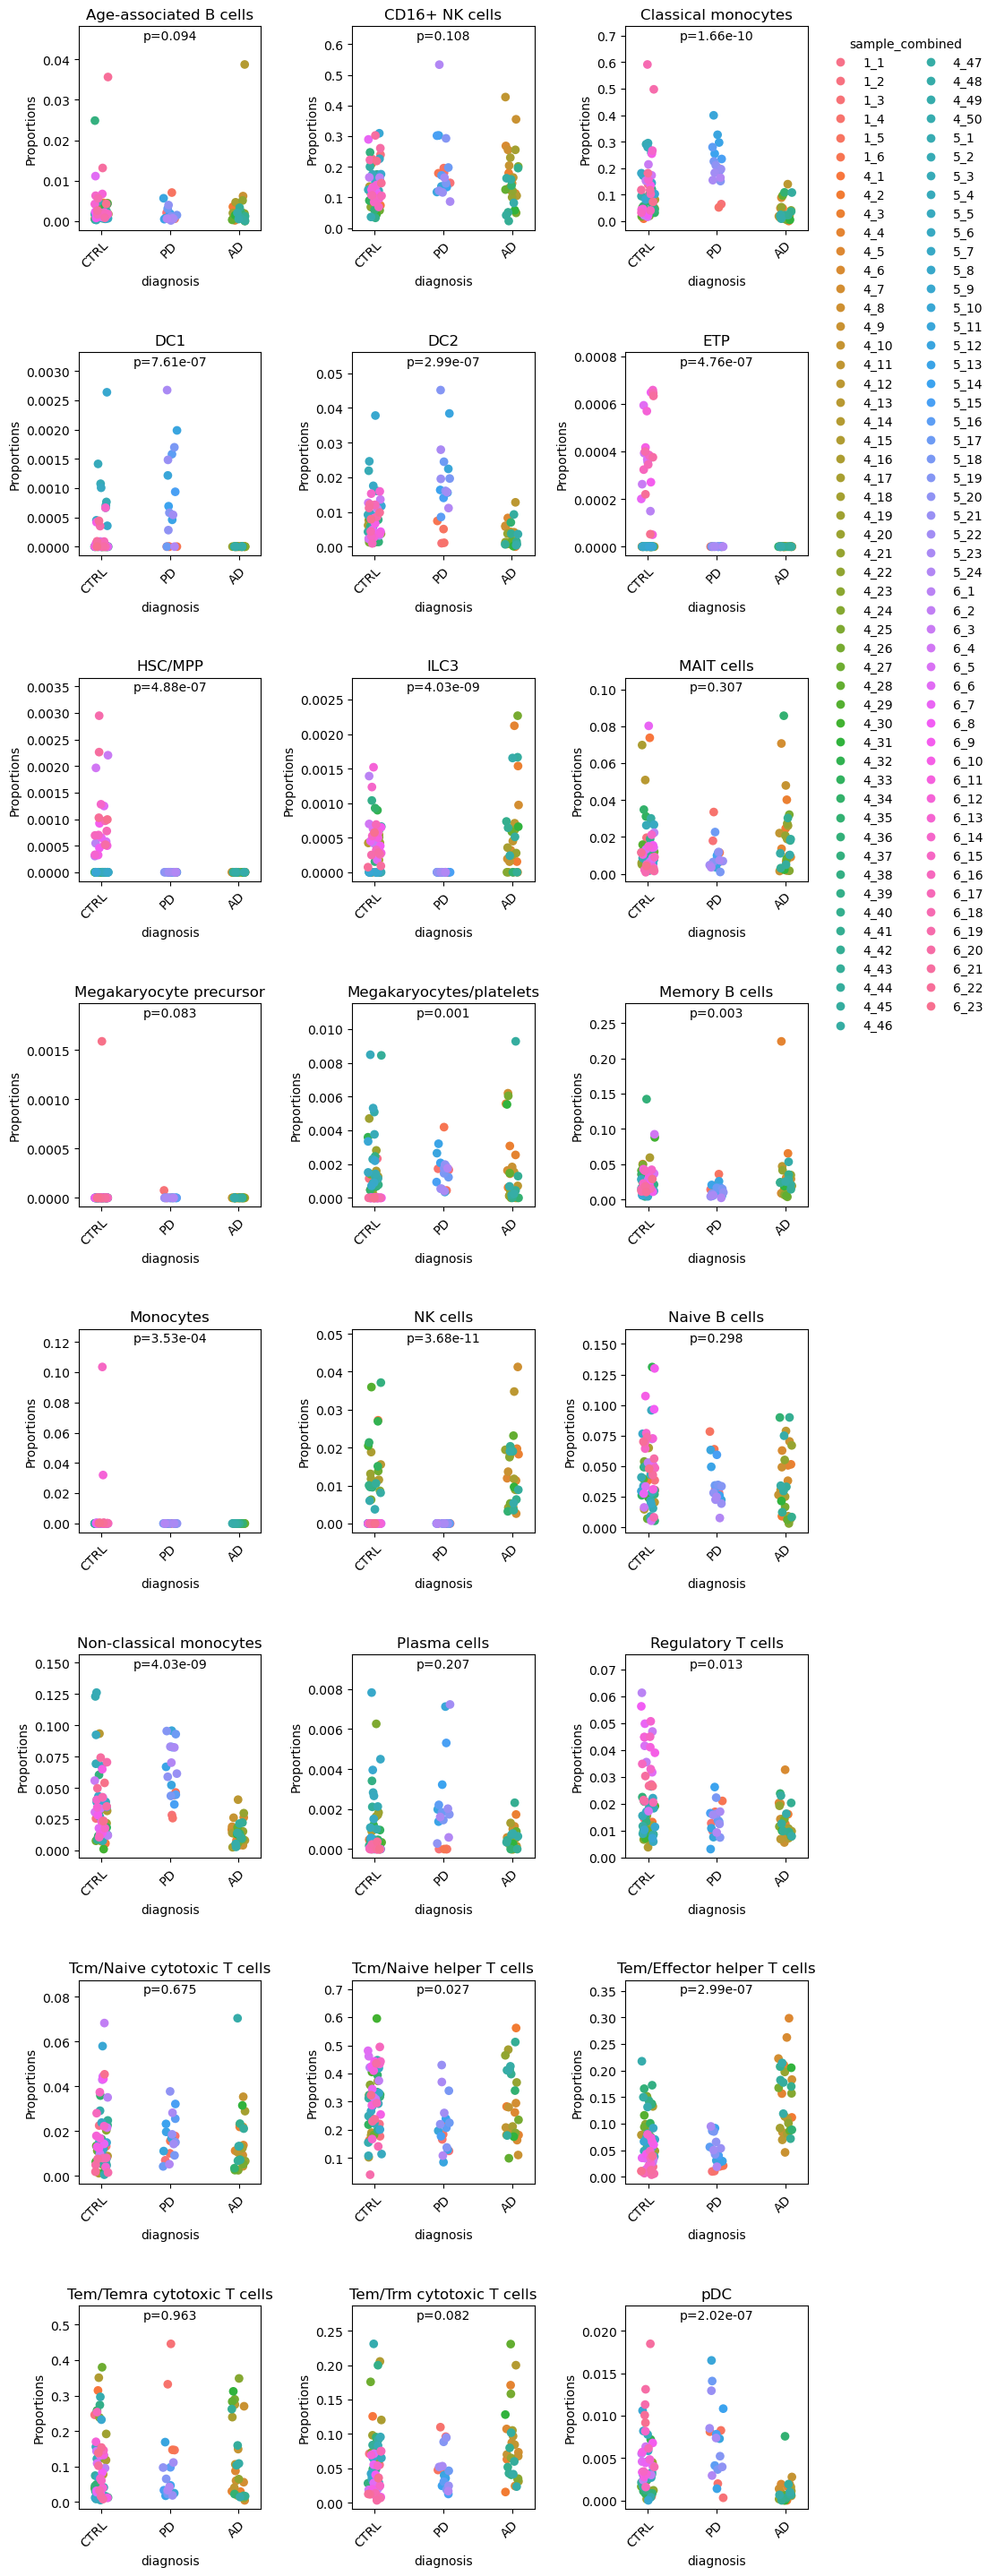

In [28]:
out.plot()

In [29]:
adata

AnnData object with n_obs × n_vars = 880872 × 12711
    obs: 'age', 'gender', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'dataset', 'sample_combined', 'diagnosis'
    var: 'feature_types', 'mt', 'gene_symbols', 'genome', 'gene_versions', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'dataset_colors', 'hvg', 'neighbors', 'pca', 'sample_combined_colors', 'scANVI', 'umap'
    obsm: 'X_pca', 'X_scANVI', 'X_umap_scANVI', 'X_umap_unintegrated'
    varm: 'PCs'
    layers: 'counts', 'log1p_norm'
    obsp: 'connectivities', 'connectivities_unintegrated', 'distances', 'distances_uninteg

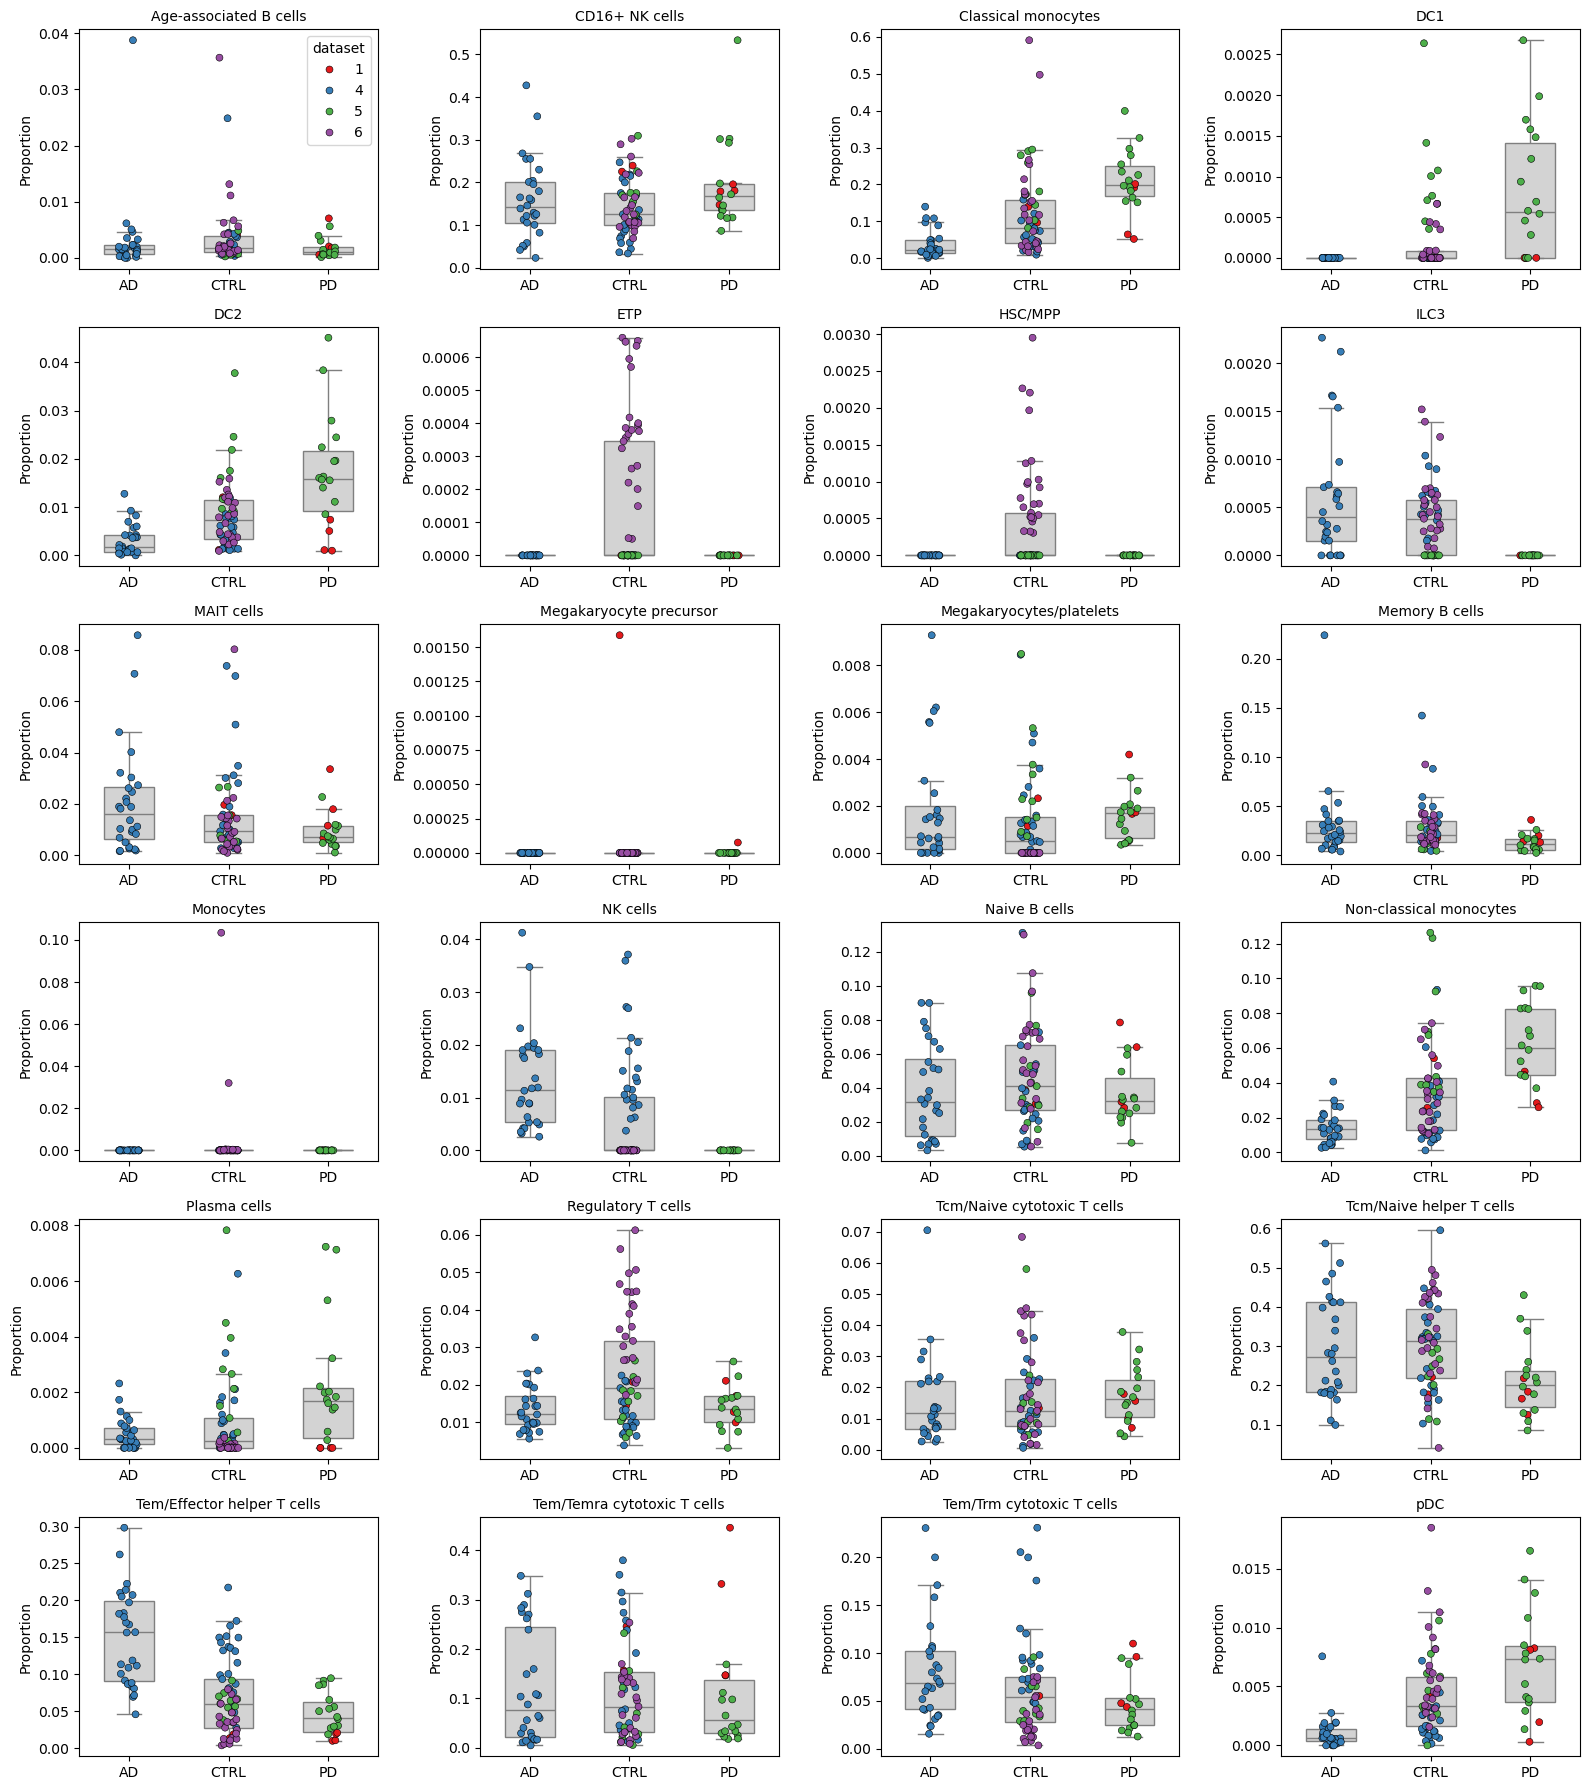

In [30]:
# Building plot manually from out.props and adata.obs, to get colours by dataset (to observe ifm 0 proportions are driven by none in that dataset vs diagnosis group)

# 1. Reshape scanpro's per-sample proportions to long form
props_long = (
    out.props.reset_index()
    .rename(columns={out.props.index.name or "index": "sample_combined"})
    .melt(id_vars="sample_combined", var_name="celltypist_cell_label_fine", value_name="proportion")
)

# 2. Attach dataset (and diagnosis) info from adata.obs
sample_meta = (
    adata.obs[["sample_combined", "dataset", "diagnosis"]]
    .drop_duplicates()
)
props_long = props_long.merge(sample_meta, on="sample_combined", how="left")

# 3. Per-cluster boxplot with dots coloured by dataset
clusters = props_long["celltypist_cell_label_fine"].unique().tolist()
n_clusters = len(clusters)
n_cols = 4
n_rows = (n_clusters + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), sharey=False)
axes = axes.flatten()

for ax, cluster in zip(axes, clusters):
    sub = props_long[props_long["celltypist_cell_label_fine"] == cluster]

    sns.boxplot(
        data=sub, x="diagnosis", y="proportion",
        ax=ax, color="lightgrey", showfliers=False, width=0.5,
    )
    sns.stripplot(
        data=sub, x="diagnosis", y="proportion", hue="dataset",
        ax=ax, dodge=False, palette="Set1", size=5, edgecolor="black", linewidth=0.4,
    )
    ax.set_title(cluster, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Proportion")

    # only show legend on the first subplot
    if ax != axes[0] and ax.get_legend() is not None:
        ax.get_legend().remove()

# hide unused subplots
for ax in axes[n_clusters:]:
    ax.set_visible(False)

plt.tight_layout()
# plt.savefig("Figures/scanpro_by_dataset.svg", bbox_inches="tight")
plt.show()

[INFO] There are 2 conditions. T-Test will be performed...
[INFO] Done!


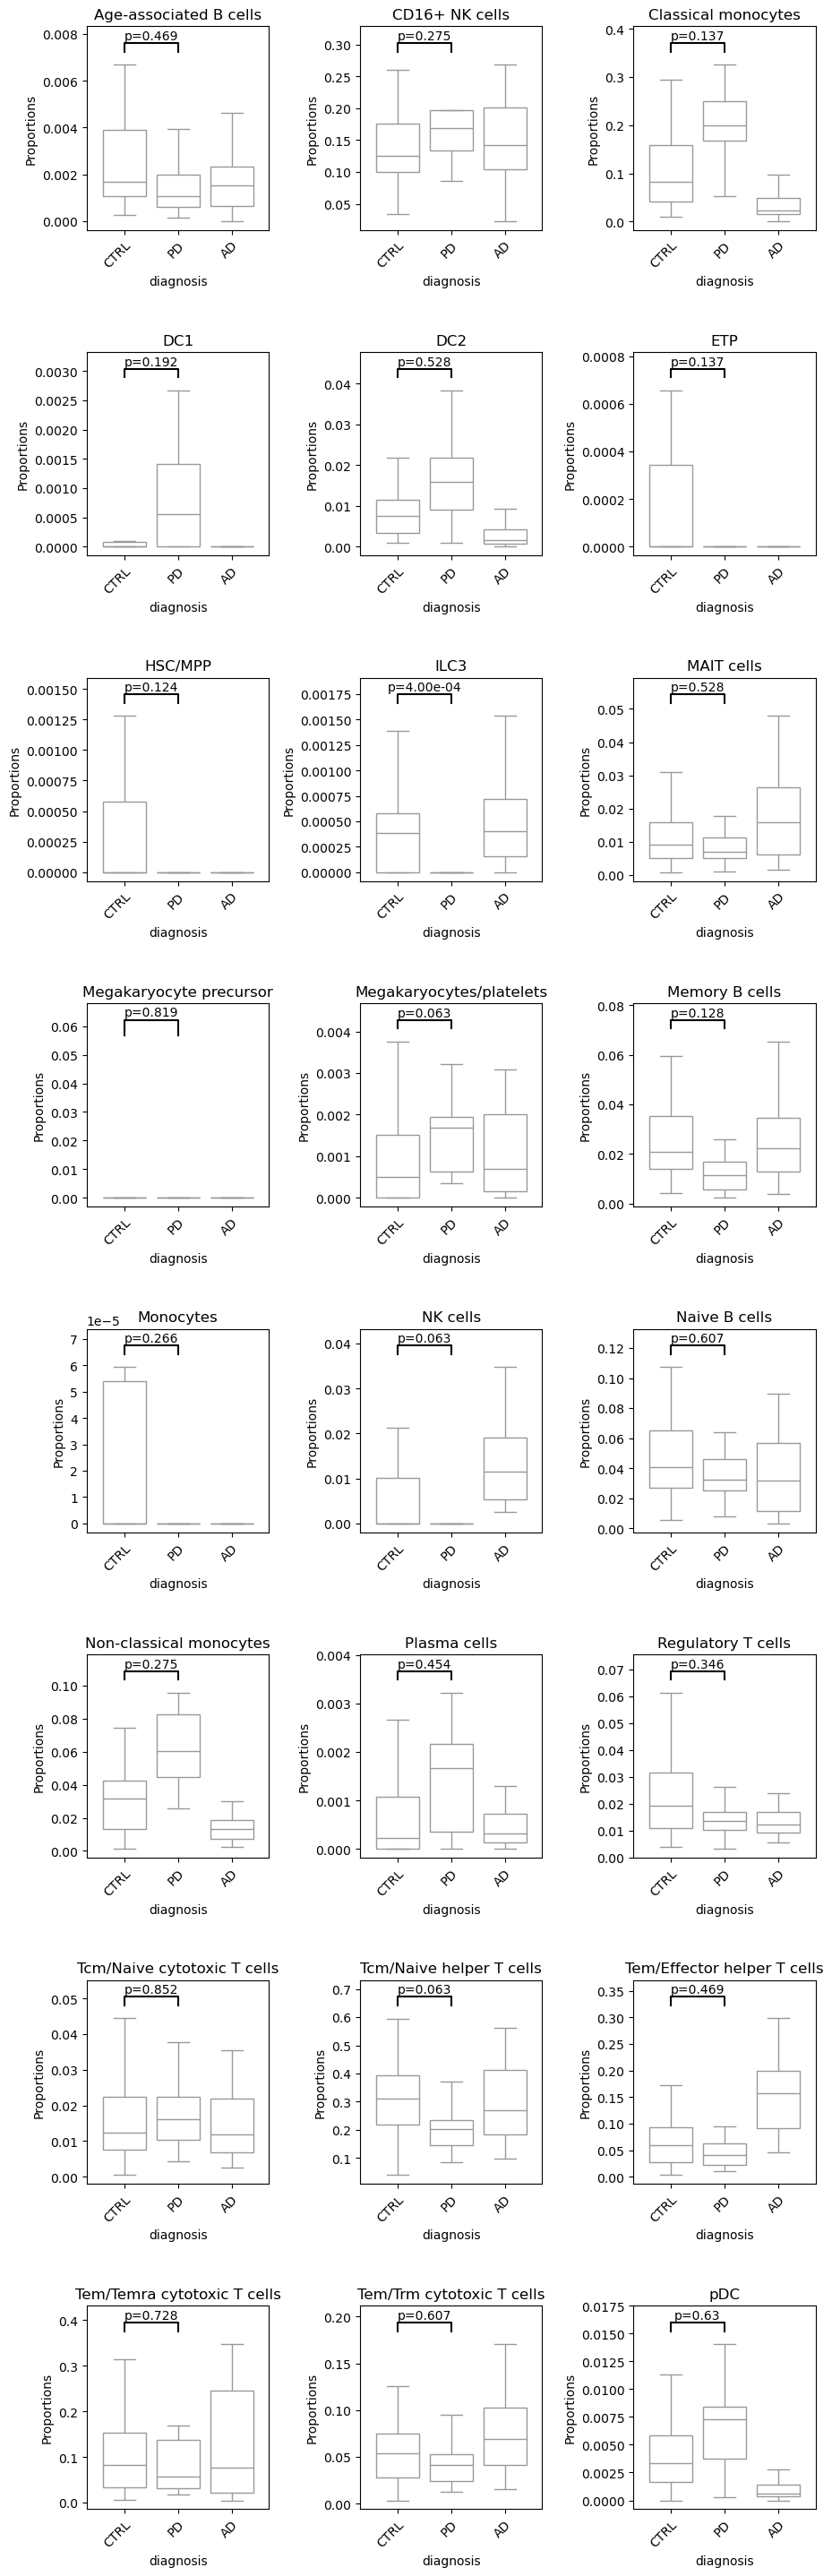

In [34]:
# Posthoc testing (testing all three comparisons)

# Comparison 1: PD vs CTRL

out2 = scanpro(adata, samples_col='sample_combined', clusters_col='celltypist_cell_label_fine', conds_col='diagnosis', conditions = ["PD", "CTRL"], covariates = ['gender']) 
out2.results

out2.plot(kind='boxplot')




[INFO] There are 2 conditions. T-Test will be performed...
[INFO] Done!


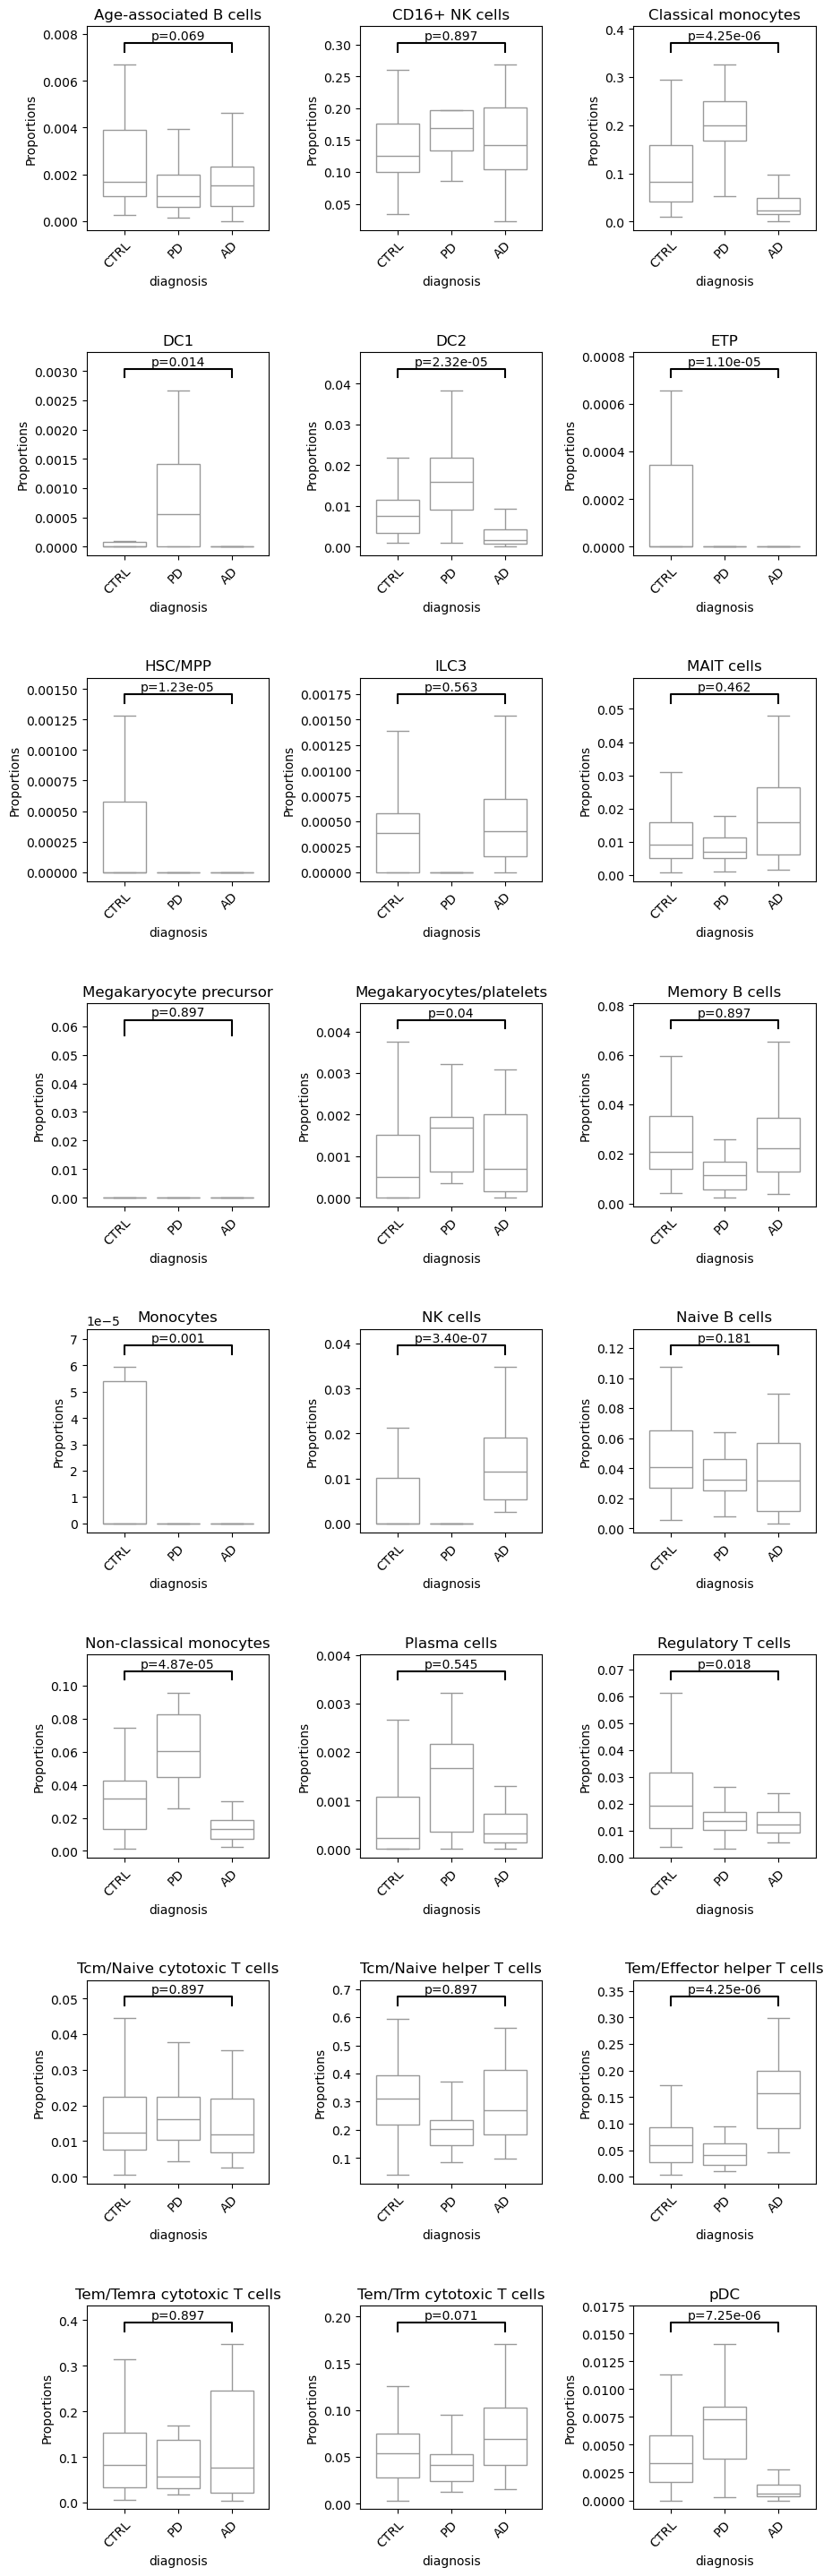

In [35]:
# Comparison 2: AD vs CTRL

out3 = scanpro(adata, samples_col='sample_combined', clusters_col='celltypist_cell_label_fine', conds_col='diagnosis', conditions = ["AD", "CTRL"]) 
out3.results

out3.plot(kind='boxplot')

[INFO] There are 2 conditions. T-Test will be performed...
[INFO] Done!


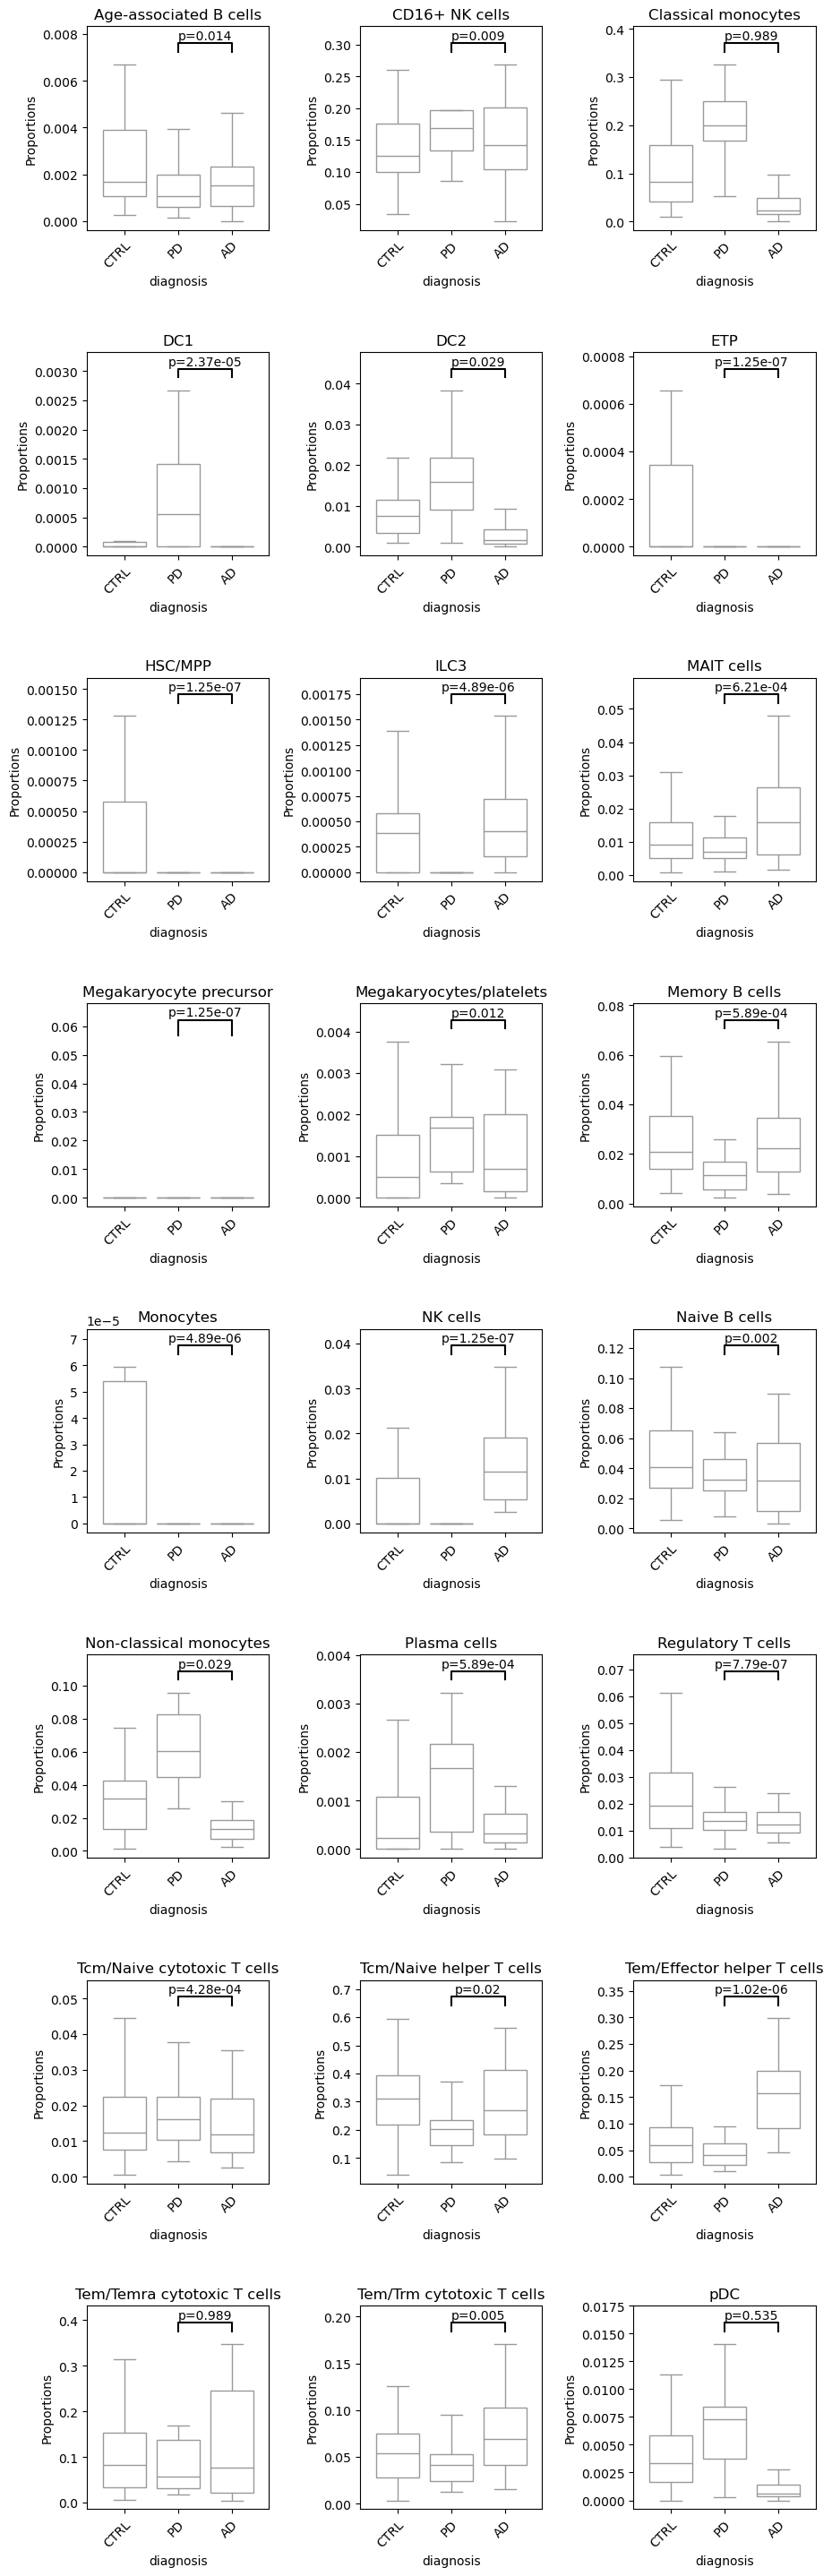

In [33]:
# Comparison 3: PD vs AD

out4 = scanpro(adata, samples_col='sample_combined', clusters_col='celltypist_cell_label_fine', conds_col='diagnosis', conditions = ["PD", "AD"], covariates = ['dataset','gender']) 
out4.results

out4.plot(kind='boxplot')

In [19]:
# do scatterplot scanpro (per dataset)
# posthocs
# comment on cell types with 0 for AD/PD, do they exist only in one dataset? (more cells in CTRL dataset) monocytes, nk etc. dont reannotate
# make into table (show only few)
# do coarse analysis, to fix issue of subgrouped cell types

[INFO] There are more than 2 conditions. ANOVA will be performed...
[INFO] Done!


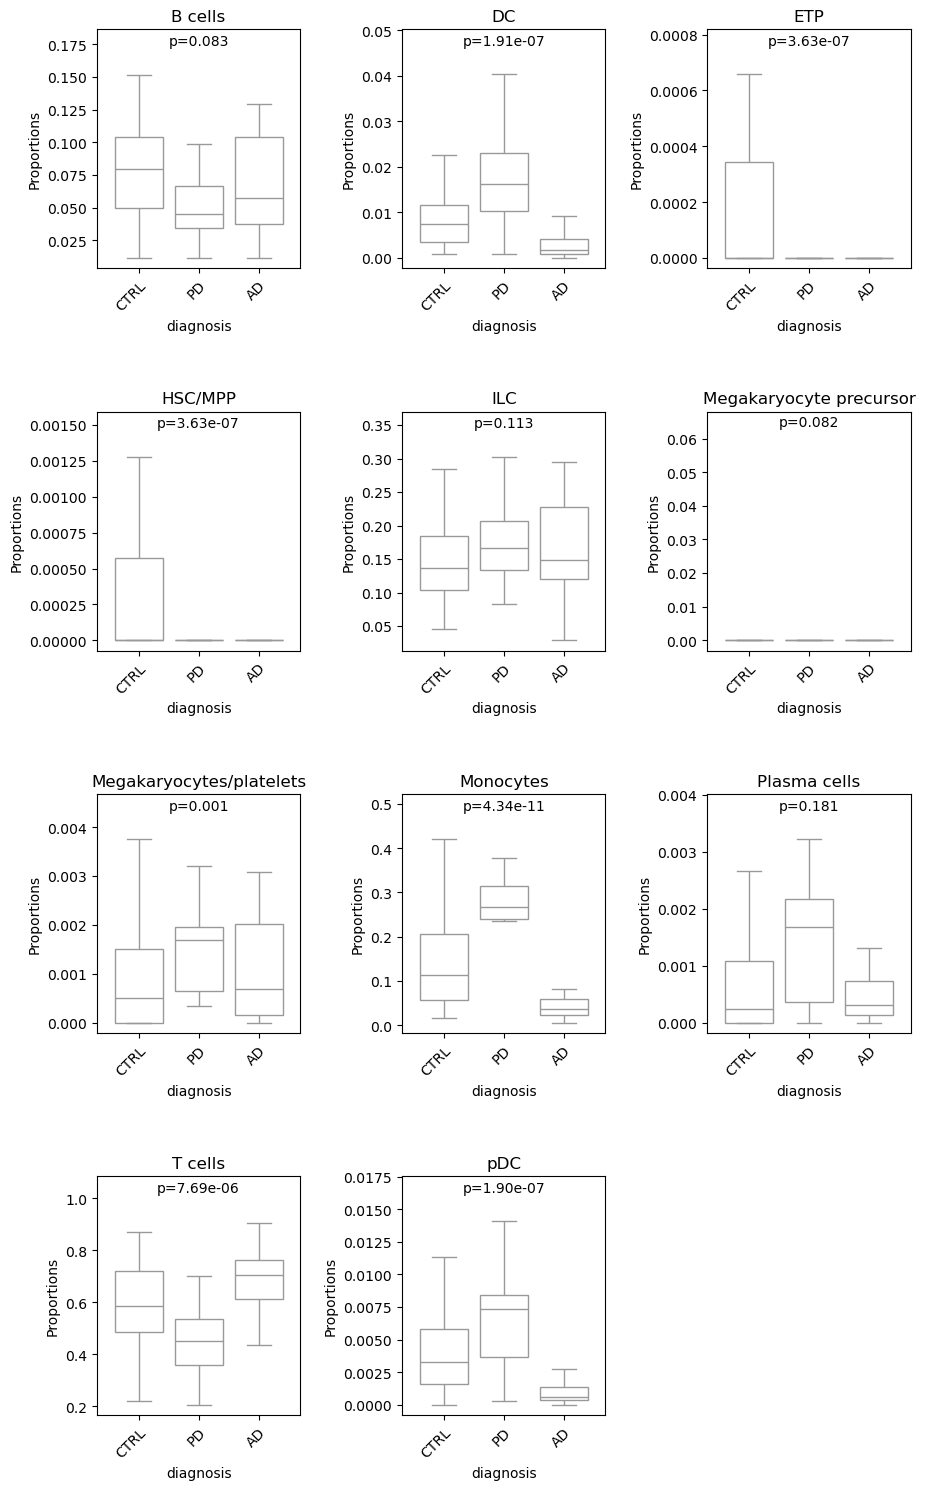

In [36]:
# redo with coarse cell types

out_coarse = scanpro(adata, samples_col='sample_combined', clusters_col='celltypist_cell_label_coarse', conds_col='diagnosis') 
out_coarse.results

out_coarse.plot(kind='boxplot')

[INFO] There are 2 conditions. T-Test will be performed...
[INFO] Done!


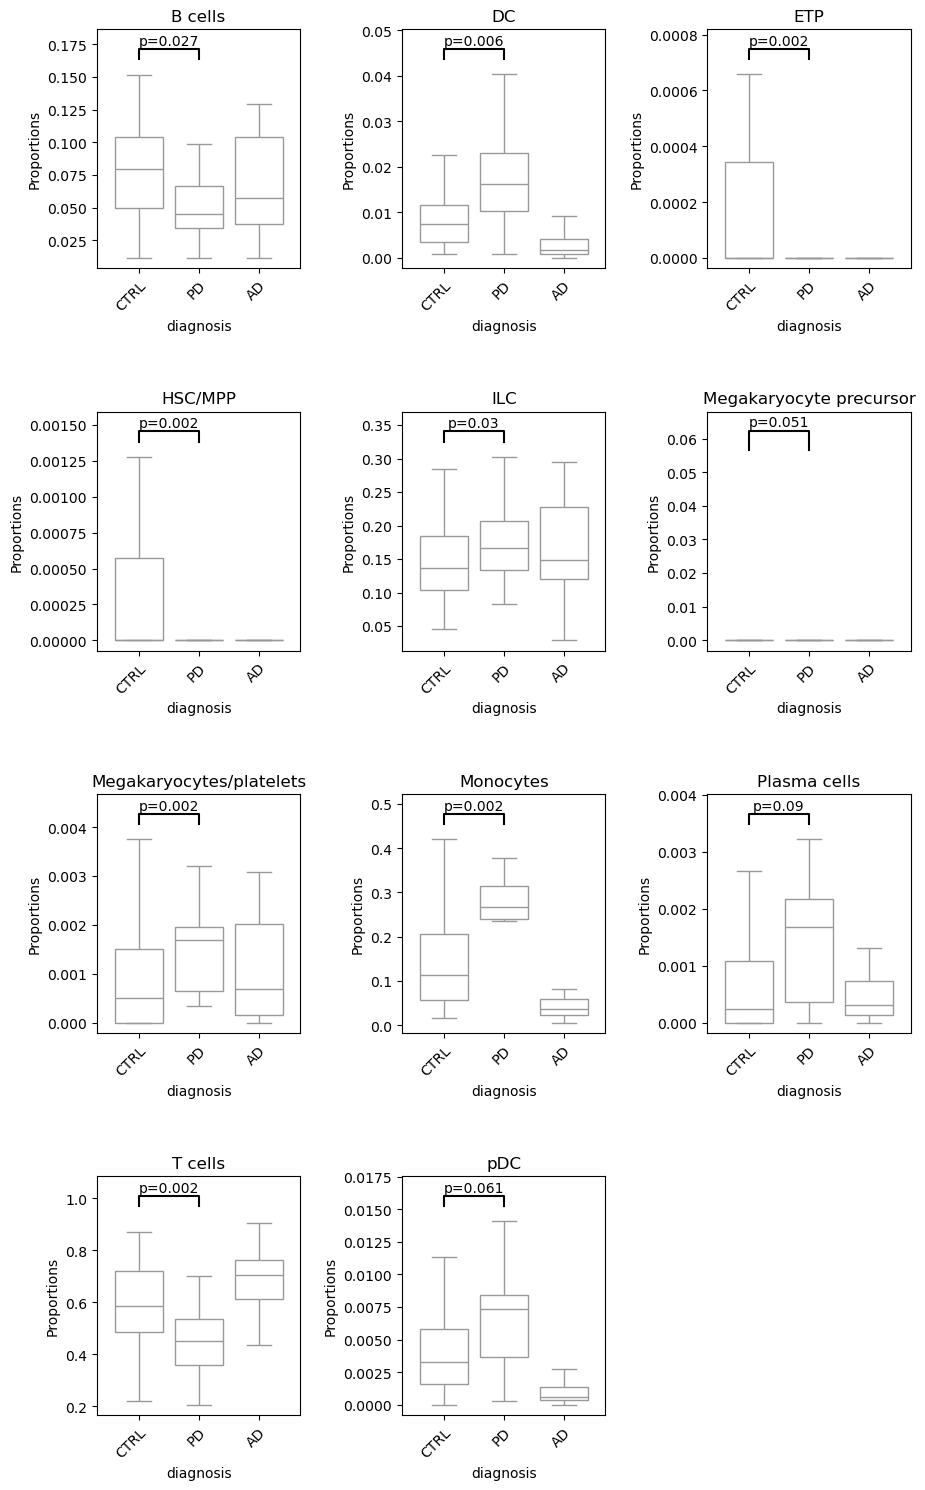

In [37]:
# coarse pairwise

out_coarse1 = scanpro(adata, samples_col='sample_combined', clusters_col='celltypist_cell_label_coarse', conds_col='diagnosis', conditions = ["PD", "CTRL"]) 
out_coarse1.results

out_coarse1.plot(kind='boxplot')

[INFO] There are 2 conditions. T-Test will be performed...
[INFO] Done!


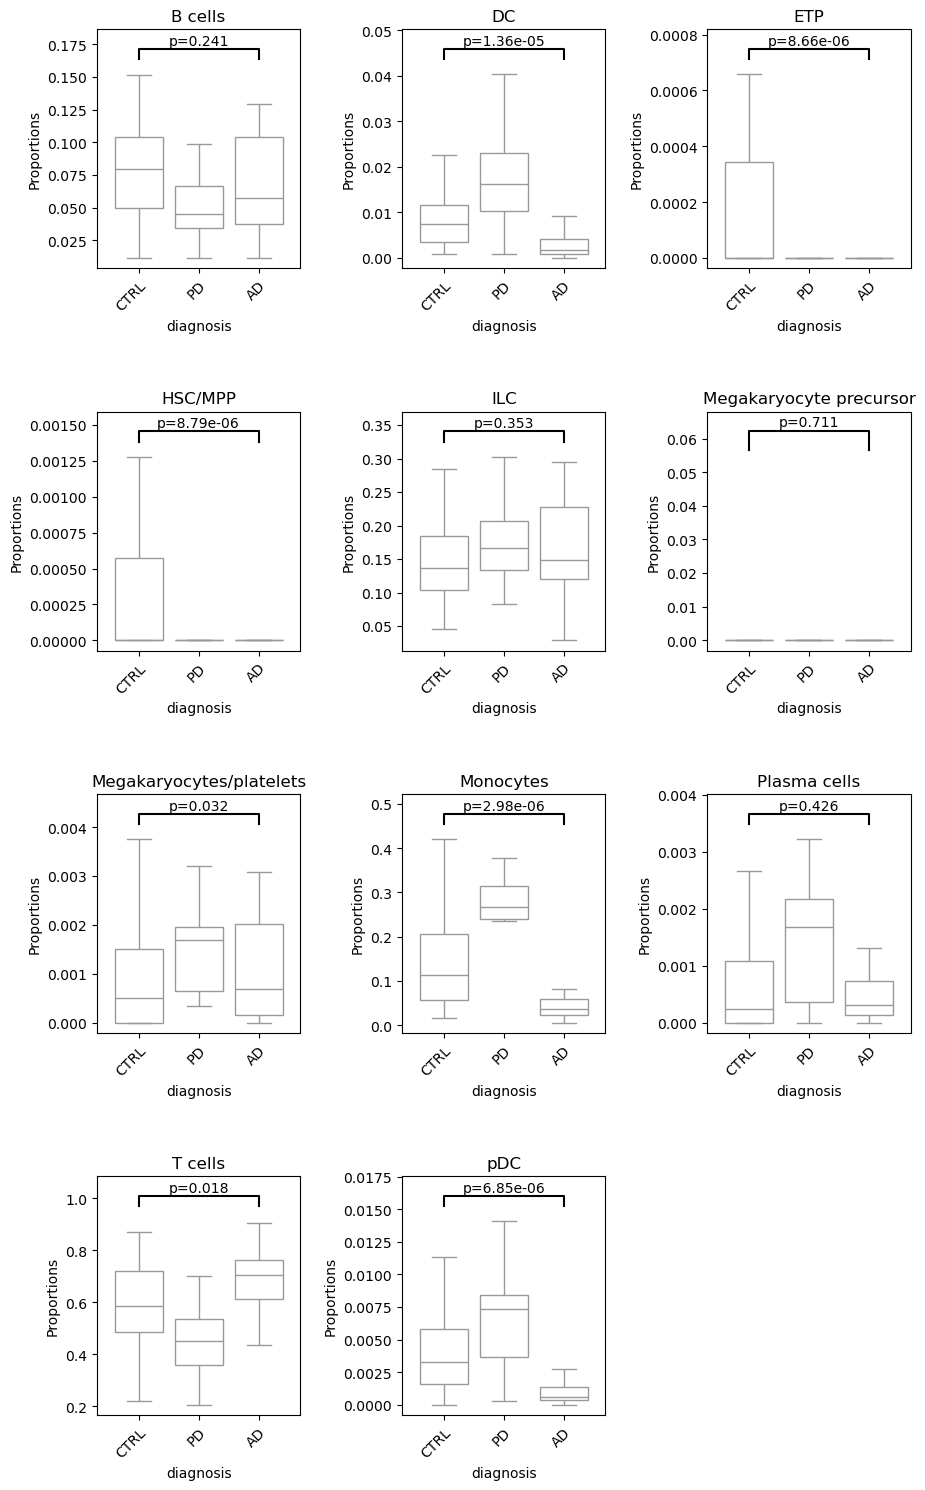

In [38]:
out_coarse2 = scanpro(adata, samples_col='sample_combined', clusters_col='celltypist_cell_label_coarse', conds_col='diagnosis', conditions = ["AD", "CTRL"]) 
out_coarse2.results

out_coarse2.plot(kind='boxplot')

[INFO] There are 2 conditions. T-Test will be performed...


[INFO] Done!


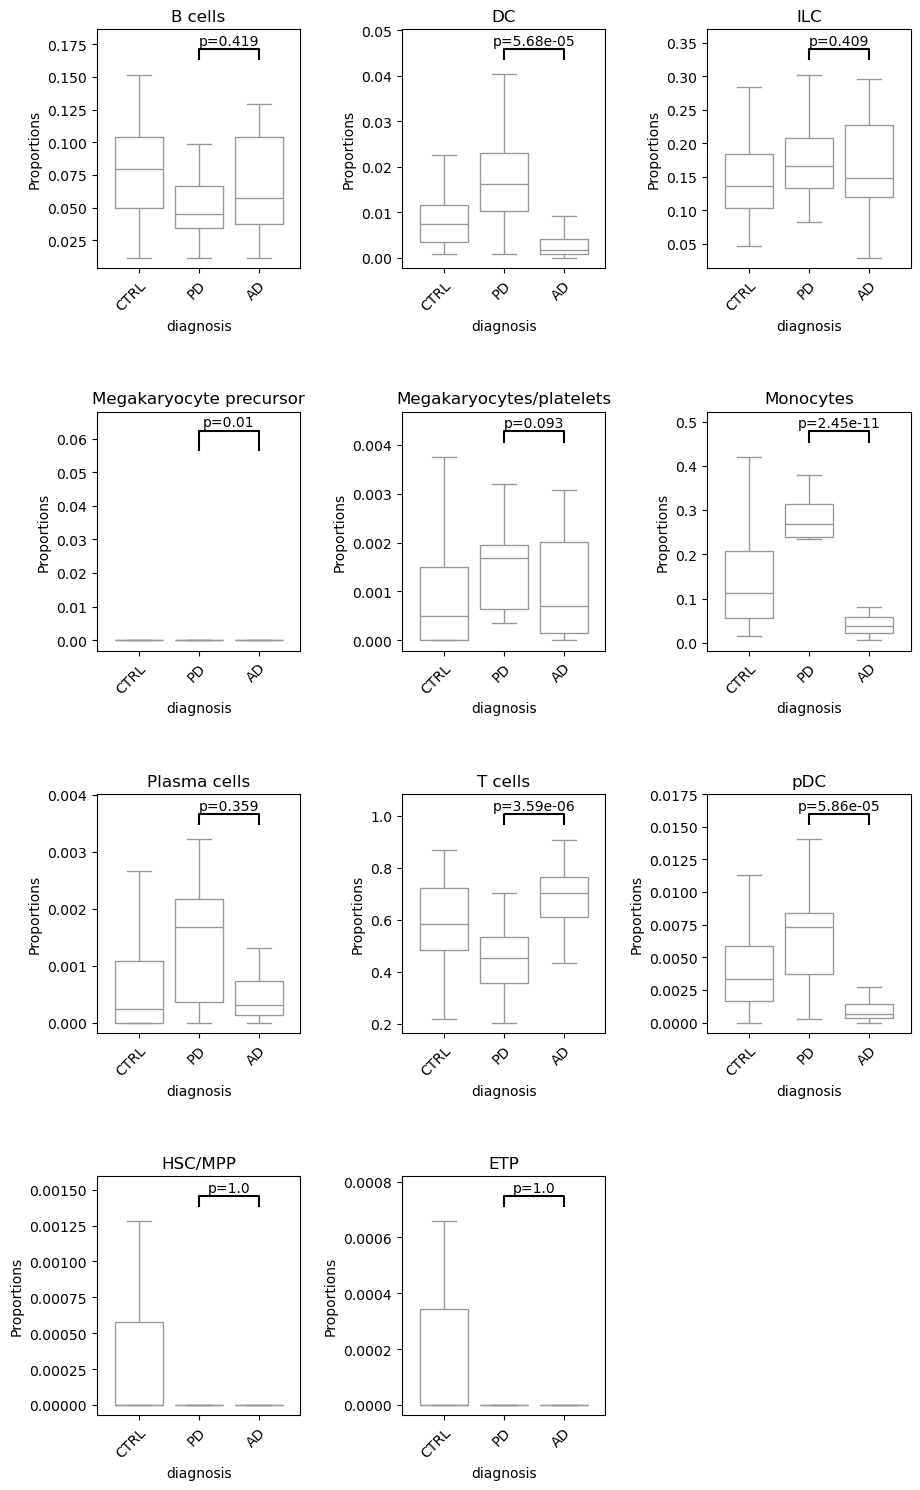

In [39]:

out_coarse3 = scanpro(adata, samples_col='sample_combined', clusters_col='celltypist_cell_label_coarse', conds_col='diagnosis', conditions = ["PD", "AD"]) 
out_coarse3.results

out_coarse3.plot(kind='boxplot')

In [ ]:
# # for power analysis

# # get cell fractions per sammple, mean and standard deviation per group

# # counts table: rows = samples, columns = cell types
# counts = sccoda_data["coda"].X

# # convert to dataframe
# counts_df = pd.DataFrame(
#     counts,
#     index=sccoda_data["coda"].obs_names,
#     columns=sccoda_data["coda"].var_names
# )

# # calculate fractions per sample
# fractions = counts_df.div(counts_df.sum(axis=1), axis=0)

# # add metadata (e.g. diagnosis)
# fractions["diagnosis"] = sccoda_data["coda"].obs["diagnosis"].values

# fractions

celltypist_cell_label_fine,Age-associated B cells,CD16+ NK cells,Classical monocytes,DC1,DC2,ETP,HSC/MPP,ILC3,MAIT cells,Megakaryocyte precursor,...,Non-classical monocytes,Plasma cells,Regulatory T cells,Tcm/Naive cytotoxic T cells,Tcm/Naive helper T cells,Tem/Effector helper T cells,Tem/Temra cytotoxic T cells,Tem/Trm cytotoxic T cells,pDC,diagnosis
scCODA_sample_id,,,,,,,,,,,,,,,,,,,,,
1_1,0.001797,0.225300,0.139874,0.000053,0.012053,0.000053,0.000053,0.000053,0.015542,0.001586,...,0.054025,0.000053,0.020828,0.022519,0.220860,0.018819,0.156579,0.055188,0.004335,CTRL
1_2,0.004142,0.239394,0.096843,0.000071,0.001143,0.000071,0.000071,0.000071,0.019569,0.000071,...,0.025568,0.000071,0.014569,0.013284,0.177260,0.013569,0.245536,0.071276,0.002571,CTRL
1_3,0.002039,0.147544,0.064862,0.000038,0.000982,0.000038,0.000038,0.000038,0.017896,0.000076,...,0.028316,0.000038,0.009967,0.007022,0.125496,0.009892,0.445351,0.096047,0.000302,PD
1_4,0.001724,0.180643,0.052457,0.000062,0.001108,0.000062,0.000062,0.000062,0.033493,0.000062,...,0.025859,0.000062,0.012806,0.017855,0.166236,0.010590,0.331609,0.109839,0.001970,PD
1_5,0.007038,0.195623,0.191445,0.000055,0.005058,0.000055,0.000055,0.000055,0.006598,0.000055,...,0.046404,0.000055,0.017044,0.010117,0.183967,0.019353,0.146360,0.047614,0.008247,PD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6_5,0.001206,0.118699,0.016994,0.000026,0.002255,0.000367,0.000577,0.000629,0.014319,0.000026,...,0.030632,0.000052,0.041542,0.021610,0.461317,0.034776,0.109100,0.071492,0.004039,CTRL
6_6,0.011112,0.095906,0.034405,0.000030,0.003744,0.000594,0.001248,0.000178,0.008676,0.000030,...,0.017826,0.000059,0.031731,0.044447,0.480837,0.012657,0.131202,0.028879,0.004575,CTRL
6_7,0.001304,0.289276,0.032053,0.000025,0.004815,0.000201,0.000652,0.000451,0.080257,0.000025,...,0.012941,0.000025,0.049759,0.014346,0.344854,0.035413,0.031701,0.055327,0.004414,CTRL


In [ ]:
# summary = fractions.groupby("diagnosis").agg(["mean", "std"])

# summary

celltypist_cell_label_fine Age-associated B cells           CD16+ NK cells  \
                                             mean       std           mean   
diagnosis                                                                    
CTRL                                     0.003458  0.005782       0.144671   
PD                                       0.001855  0.001908       0.195693   
AD                                       0.003131  0.007145       0.159483   

celltypist_cell_label_fine           Classical monocytes                 DC1  \
                                 std                mean       std      mean   
diagnosis                                                                      
CTRL                        0.067126            0.120133  0.113299  0.000255   
PD                          0.105385            0.209872  0.084117  0.000830   
AD                          0.093593            0.037816  0.036889  0.000087   

celltypist_cell_label_fine                 DC2            ...  \
                                 std      mean       std  ...   
diagnosis                                                 ...   
CTRL                        0.000436  0.008134  0.006654  ...   
PD                          0.000774  0.017178  0.011694  ...   
AD                          0.000032  0.003163  0.003157  ...   

celltypist_cell_label_fine Tcm/Naive helper T cells            \
                                               mean       std   
diagnosis                                                       
CTRL                                       0.300348  0.115983   
PD                                         0.212194  0.091630   
AD                                         0.293986  0.129528   

celltypist_cell_label_fine Tem/Effector helper T cells            \
                                                  mean       std   
diagnosis                                                          
CTRL                                          0.068485  0.050956   
PD                                            0.046091  0.028366   
AD                                            0.149255  0.064265   

celltypist_cell_label_fine Tem/Temra cytotoxic T cells            \
                                                  mean       std   
diagnosis                                                          
CTRL                                          0.111454  0.096259   
PD                                            0.104517  0.115762   
AD                                            0.121221  0.113762   

celltypist_cell_label_fine Tem/Trm cytotoxic T cells                 pDC  \
                                                mean       std      mean   
diagnosis                                                                  
CTRL                                        0.061787  0.049336  0.004270   
PD                                          0.047649  0.030055  0.006944   
AD                                          0.081786  0.054112  0.001100   

celltypist_cell_label_fine            
                                 std  
diagnosis                             
CTRL                        0.003564  
PD                          0.004513  
AD                          0.001438  

[3 rows x 48 columns]

In [ ]:
# # in each run, after prepare()
# print(sccoda_data["coda"].uns.get("scCODA_params"))   # should mention the reference cell type chosen
# # or look for it in the printed prepare output

{'formula': 'diagnosis + dataset', 'reference_cell_type': 'ETP', 'reference_index': np.int64(5), 'automatic_reference_absence_threshold': 0.05, 'covariate_names': ['diagnosis[T.PD]', 'diagnosis[T.AD]', 'dataset[T.1]', 'dataset[T.4]', 'dataset[T.5]'], 'mcmc': {'init_params': {'sigma_d': array([[1.],
       [1.],
       [1.],
       [1.],
       [1.]]), 'b_offset': array([[-1.60383681,  0.06409991,  0.7408913 ,  0.15261919,  0.86374389,
         2.91309922, -1.47882336,  0.94547297, -1.66613546,  0.34374458,
        -0.51244371,  1.32375896, -0.86028019,  0.5194932 , -1.26514372,
        -2.15913901,  0.43473395,  1.73328932,  0.52013416, -1.00216579,
         0.26834554,  0.7671747 ,  1.19127203],
       [-1.15741081,  0.6962794 ,  0.35138369, -0.03241508,  0.01318158,
        -0.67924997, -0.62053203,  1.33121422,  0.25883851, -0.48148392,
        -2.49178962, -0.87656377, -0.50550913, -1.28312917, -1.33032842,
         0.82599258, -0.24721501, -1.69970612, -1.33515287, -0.29963889,
  